<a href="https://colab.research.google.com/github/HardikSingh8/Neural-Connectome-Growth-Simulation/blob/main/Connectome.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import torch

torch_version = torch.__version__.split('+')[0]
cuda_version  = torch.version.cuda

print(f"PyTorch version : {torch_version}")
print(f"CUDA version    : {cuda_version}")
print(f"GPU available   : {torch.cuda.is_available()}")

PyTorch version : 2.10.0
CUDA version    : 12.8
GPU available   : True


In [2]:
import subprocess, sys

def run(cmd):
    print(f"\n▶ {cmd}")
    result = subprocess.run(cmd, shell=True, capture_output=True, text=True)
    if result.returncode != 0:
        print("STDERR:", result.stderr[-500:])
    else:
        print("Done")

run("pip install -q torch-geometric")
run("pip install -q torch-scatter torch-sparse -f https://data.pyg.org/whl/torch-2.5.0+cu121.html")


run("pip install -q networkx matplotlib numpy scikit-learn")

print("\n All installations complete.")


▶ pip install -q torch-geometric
Done

▶ pip install -q torch-scatter torch-sparse -f https://data.pyg.org/whl/torch-2.5.0+cu121.html
Done

▶ pip install -q networkx matplotlib numpy scikit-learn
Done

 All installations complete.


In [3]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from collections import defaultdict
import random

import networkx as nx

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch_geometric.data import Data
from torch_geometric.nn import GCNConv


from sklearn.decomposition import PCA


%matplotlib inline
plt.rcParams['figure.dpi'] = 120

print("All libraries imported successfully.")

/usr/local/lib/python3.12/dist-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: Could not load this library: /usr/local/lib/python3.12/dist-packages/torch_scatter/_version_cuda.so
  import torch_geometric.typing
/usr/local/lib/python3.12/dist-packages/torch_geometric/__init__.py:4: UserWarning: An issue occurred while importing 'torch-sparse'. Disabling its usage. Stacktrace: Could not load this library: /usr/local/lib/python3.12/dist-packages/torch_sparse/_version_cuda.so
  import torch_geometric.typing


All libraries imported successfully.


In [4]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


INITIAL_NEURONS    = 5
TIMESTEPS          = 25
CONNECTIONS_PER_STEP = 2
MAX_CONNECTIONS    = 3


SPACE_SIZE         = 10.0


ALPHA              = 0.5
BETA               = 0.5


SNAPSHOT_STEPS     = [0, 5, 10, 20]


DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print("=" * 45)
print("  Neural Connectome Simulation — Config")
print("=" * 45)
print(f"  Seed neurons       : {INITIAL_NEURONS}")
print(f"  Timesteps          : {TIMESTEPS}")
print(f"  Connections/step   : {CONNECTIONS_PER_STEP}–{MAX_CONNECTIONS}")
print(f"  Space size         : {SPACE_SIZE} x {SPACE_SIZE}")
print(f"  Attachment weight  : α = {ALPHA}")
print(f"  Proximity weight   : β = {BETA}")
print(f"  Snapshot steps     : {SNAPSHOT_STEPS}")
print(f"  Device (GNN)       : {DEVICE}")
print("=" * 45)
print("\n Phase 1 complete — ready for Phase 2!")


  Neural Connectome Simulation — Config
  Seed neurons       : 5
  Timesteps          : 25
  Connections/step   : 2–3
  Space size         : 10.0 x 10.0
  Attachment weight  : α = 0.5
  Proximity weight   : β = 0.5
  Snapshot steps     : [0, 5, 10, 20]
  Device (GNN)       : cuda

 Phase 1 complete — ready for Phase 2!


In [5]:
G = nx.DiGraph()

initial_positions = {}
for i in range(INITIAL_NEURONS):
    pos = (round(random.uniform(0, SPACE_SIZE), 4),
           round(random.uniform(0, SPACE_SIZE), 4))
    G.add_node(i, pos=pos)
    initial_positions[i] = pos

print(f" {INITIAL_NEURONS} seed neurons created\n")
print(f"{'Neuron':<10} {'Position':>20}")
print("-" * 32)
for node, data in G.nodes(data=True):
    print(f"  Node {node:<5} → pos {data['pos']}")

 5 seed neurons created

Neuron                 Position
--------------------------------
  Node 0     → pos (6.3943, 0.2501)
  Node 1     → pos (2.7503, 2.2321)
  Node 2     → pos (7.3647, 6.767)
  Node 3     → pos (8.9218, 0.8694)
  Node 4     → pos (4.2192, 0.298)


In [6]:
def euclidean_distance(pos1, pos2):
    """Compute Euclidean distance between two 2D positions."""
    return np.sqrt((pos1[0] - pos2[0])**2 + (pos1[1] - pos2[1])**2)

def compute_connection_probability(G, source, targets):
    """
    Combined probability score for source neuron connecting to each target.
    Blend of:
      - Preferential Attachment : proportional to target degree
      - Spatial Proximity       : inversely proportional to distance
    Returns normalized probability array over all targets.
    """
    source_pos = G.nodes[source]['pos']
    scores = []

    for t in targets:

        degree     = G.degree(t) + 1
        pref_score = degree ** ALPHA


        dist       = euclidean_distance(source_pos, G.nodes[t]['pos'])
        prox_score = 1.0 / (dist + 1e-6)
        prox_score = prox_score ** BETA


        scores.append(pref_score * prox_score)

    scores = np.array(scores, dtype=float)


    total = scores.sum()
    if total == 0:
        return np.ones(len(targets)) / len(targets)
    return scores / total



nodes = list(G.nodes())


for node in nodes:
    candidates = [n for n in nodes if n != node]
    probs      = compute_connection_probability(G, node, candidates)


    sorted_candidates = [c for _, c in sorted(zip(probs, candidates), reverse=True)]
    for target in sorted_candidates[:2]:
        if not G.has_edge(node, target):
            G.add_edge(node, target)

print(f" Initial edges created")
print(f"   Nodes : {G.number_of_nodes()}")
print(f"   Edges : {G.number_of_edges()}")
print(f"\n   Edge list:")
for u, v in G.edges():
    print(f"     {u} → {v}")

 Initial edges created
   Nodes : 5
   Edges : 10

   Edge list:
     0 → 4
     0 → 3
     1 → 4
     1 → 0
     2 → 0
     2 → 1
     3 → 0
     3 → 4
     4 → 0
     4 → 1


In [7]:
def compute_metrics(G):
    """
    Compute and return key topology metrics for graph G.
    Returns a dict with node count, edge count, avg degree,
    clustering coefficient, and degree distribution.
    """
    n_nodes   = G.number_of_nodes()
    n_edges   = G.number_of_edges()

    G_und     = G.to_undirected()
    degrees   = [d for _, d in G_und.degree()]
    avg_deg   = round(np.mean(degrees), 4)  if degrees else 0.0
    clust     = round(nx.average_clustering(G_und), 4)

    deg_dist  = defaultdict(int)
    for d in degrees:
        deg_dist[d] += 1

    return {
        'n_nodes'  : n_nodes,
        'n_edges'  : n_edges,
        'avg_deg'  : avg_deg,
        'clustering': clust,
        'deg_dist' : dict(deg_dist),
    }


metrics_log   = {}
graph_snapshots = {}


metrics_log[0]     = compute_metrics(G)
graph_snapshots[0] = G.copy()

print("Metrics helper ready & timestep 0 recorded\n")
print(f"{'Metric':<25} {'Value':>10}")
print("-" * 37)
m = metrics_log[0]
print(f"  {'Nodes':<23} {m['n_nodes']:>10}")
print(f"  {'Edges':<23} {m['n_edges']:>10}")
print(f"  {'Avg Degree':<23} {m['avg_deg']:>10}")
print(f"  {'Clustering Coeff':<23} {m['clustering']:>10}")
print(f"  {'Degree Distribution':<23}  {m['deg_dist']}")

Metrics helper ready & timestep 0 recorded

Metric                         Value
-------------------------------------
  Nodes                            5
  Edges                           10
  Avg Degree                     2.8
  Clustering Coeff            0.7667
  Degree Distribution      {4: 1, 3: 2, 2: 2}


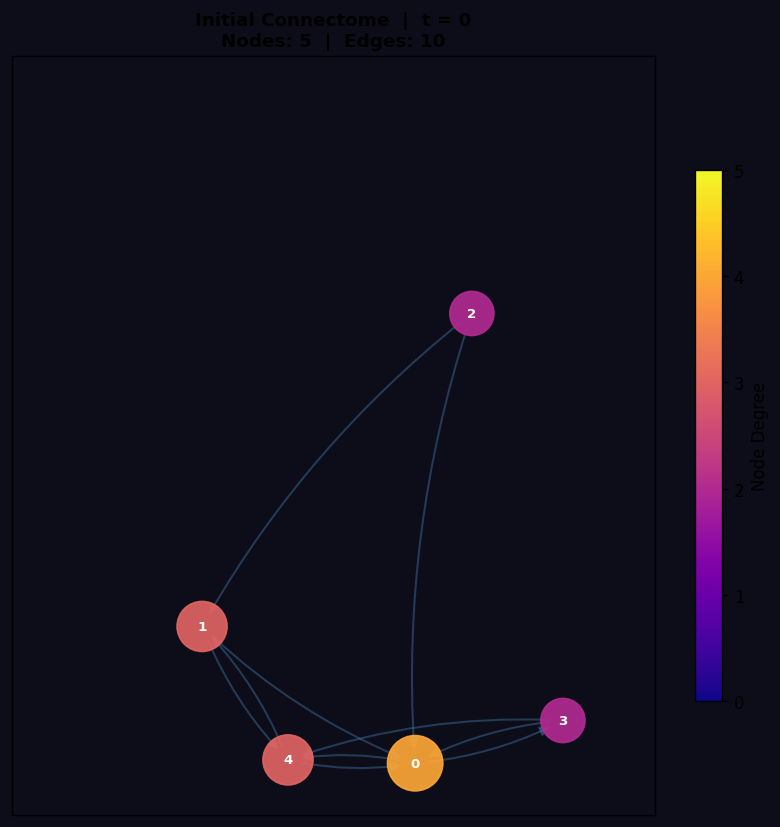

 Initial connectome visualized & saved → /content/connectome_t0.png


In [8]:
def draw_connectome(G, ax, title="Connectome", timestep=None):
    """
    Draw the connectome graph on a given matplotlib Axes.
    - Node size   ∝ degree
    - Node color  encodes degree (colormap)
    - Edges drawn with transparency
    """
    G_und    = G.to_undirected()
    pos      = nx.get_node_attributes(G, 'pos')
    degrees  = dict(G_und.degree())


    node_sizes  = [300 + degrees[n] * 200 for n in G.nodes()]
    node_colors = [degrees[n] for n in G.nodes()]


    nodes_drawn = nx.draw_networkx_nodes(
        G, pos, ax=ax,
        node_size=node_sizes,
        node_color=node_colors,
        cmap=cm.plasma,
        vmin=0,
        vmax=max(node_colors) + 1 if node_colors else 1,
        alpha=0.92
    )
    nx.draw_networkx_edges(
        G, pos, ax=ax,
        edge_color='steelblue',
        alpha=0.4,
        arrows=True,
        arrowsize=12,
        width=1.2,
        connectionstyle='arc3,rad=0.1'
    )
    nx.draw_networkx_labels(
        G, pos, ax=ax,
        font_size=8,
        font_color='white',
        font_weight='bold'
    )


    sm = plt.cm.ScalarMappable(cmap=cm.plasma,
                               norm=plt.Normalize(vmin=0,
                               vmax=max(node_colors)+1 if node_colors else 1))
    sm.set_array([])
    plt.colorbar(sm, ax=ax, label='Node Degree', shrink=0.7)

    step_label = f"  |  t = {timestep}" if timestep is not None else ""
    ax.set_title(f"{title}{step_label}\n"
                 f"Nodes: {G.number_of_nodes()}  |  "
                 f"Edges: {G.number_of_edges()}",
                 fontsize=11, fontweight='bold')
    ax.set_xlim(-0.5, SPACE_SIZE + 0.5)
    ax.set_ylim(-0.5, SPACE_SIZE + 0.5)
    ax.set_facecolor('#0d0d1a')
    ax.tick_params(left=False, bottom=False,
                   labelleft=False, labelbottom=False)


fig, ax = plt.subplots(figsize=(7, 7))
fig.patch.set_facecolor('#0d0d1a')
draw_connectome(G, ax, title="Initial Connectome", timestep=0)
plt.tight_layout()
plt.savefig('/content/connectome_t0.png', dpi=150,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(" Initial connectome visualized & saved → /content/connectome_t0.png")

In [9]:
def add_new_neuron(G):
    """
    Rule 1 — Neuron Birth:
    Add a new neuron (node) to the graph at each timestep.
    Assigns a random 2D spatial position within the defined space.

    Returns:
        new_id (int): The node ID of the newly created neuron.
    """
    new_id  = G.number_of_nodes()
    new_pos = (
        round(random.uniform(0, SPACE_SIZE), 4),
        round(random.uniform(0, SPACE_SIZE), 4)
    )
    G.add_node(new_id, pos=new_pos)
    return new_id



G_test   = G.copy()
new_node = add_new_neuron(G_test)

print("Rule 1 — Neuron Birth verified\n")
print(f"   Graph before : {G_test.number_of_nodes() - 1} nodes")
print(f"   New neuron ID: {new_node}")
print(f"   Position     : {G_test.nodes[new_node]['pos']}")
print(f"   Graph after  : {G_test.number_of_nodes()} nodes")
del G_test

Rule 1 — Neuron Birth verified

   Graph before : 5 nodes
   New neuron ID: 5
   Position     : (2.1864, 5.0536)
   Graph after  : 6 nodes


In [10]:
def preferential_attachment_scores(G, candidates):
    """
    Rule 2 — Preferential Attachment:
    Neurons with higher degree have higher probability of receiving
    new connections — simulates hub formation in neural networks.

    Score for each candidate = (degree + 1) ^ ALPHA
    The +1 ensures isolated nodes still have a nonzero chance.

    Args:
        G          : Current graph
        candidates : List of existing node IDs to score

    Returns:
        np.array of raw (unnormalized) preferential scores
    """
    G_und  = G.to_undirected()
    scores = np.array(
        [(G_und.degree(n) + 1) ** ALPHA for n in candidates],
        dtype=float
    )
    return scores


candidates   = list(G.nodes())
pa_scores    = preferential_attachment_scores(G, candidates)
pa_norm      = pa_scores / pa_scores.sum()

print("Rule 2 — Preferential Attachment verified\n")
print(f"{'Node':<8} {'Degree':<10} {'PA Score':<14} {'Probability':<12}")
print("-" * 46)
G_und = G.to_undirected()
for node, score, prob in zip(candidates, pa_scores, pa_norm):
    deg = G_und.degree(node)
    print(f"  {node:<6} {deg:<10} {score:<14.4f} {prob:<12.4f}")
print(f"\n  Higher-degree nodes → higher attachment probability ✓")

Rule 2 — Preferential Attachment verified

Node     Degree     PA Score       Probability 
----------------------------------------------
  0      4          2.2361         0.2305      
  1      3          2.0000         0.2062      
  2      2          1.7321         0.1786      
  3      2          1.7321         0.1786      
  4      3          2.0000         0.2062      

  Higher-degree nodes → higher attachment probability ✓


In [11]:
def spatial_proximity_scores(G, new_node, candidates):
    """
    Rule 3 — Spatial Proximity:
    Neurons closer in 2D space have higher probability of connecting.
    Models the biological tendency of neurons to wire with nearby cells.

    Score for each candidate = (1 / (distance + epsilon)) ^ BETA
    Epsilon prevents division by zero for overlapping positions.

    Args:
        G        : Current graph
        new_node : The newly born neuron (source of connections)
        candidates: List of existing node IDs to score

    Returns:
        np.array of raw (unnormalized) proximity scores
        np.array of actual distances (for inspection/logging)
    """
    new_pos   = G.nodes[new_node]['pos']
    distances = np.array(
        [euclidean_distance(new_pos, G.nodes[n]['pos']) for n in candidates],
        dtype=float
    )
    scores    = (1.0 / (distances + 1e-6)) ** BETA
    return scores, distances


G_test      = G.copy()
test_node   = add_new_neuron(G_test)
candidates  = [n for n in G_test.nodes() if n != test_node]

prox_scores, dists = spatial_proximity_scores(G_test, test_node, candidates)
prox_norm          = prox_scores / prox_scores.sum()

print("Rule 3 — Spatial Proximity verified\n")
print(f"  New neuron {test_node} position: {G_test.nodes[test_node]['pos']}\n")
print(f"{'Node':<8} {'Distance':<14} {'Prox Score':<14} {'Probability':<12}")
print("-" * 50)
for node, dist, score, prob in zip(candidates, dists, prox_scores, prox_norm):
    print(f"  {node:<6} {dist:<14.4f} {score:<14.4f} {prob:<12.4f}")
print(f"\n  Closer nodes → higher proximity probability ✓")
del G_test

Rule 3 — Spatial Proximity verified

  New neuron 5 position: (0.2654, 1.9884)

Node     Distance       Prox Score     Probability 
--------------------------------------------------
  0      6.3706         0.3962         0.1808      
  1      2.4968         0.6329         0.2888      
  2      8.5577         0.3418         0.1560      
  3      8.7284         0.3385         0.1544      
  4      4.3000         0.4822         0.2200      

  Closer nodes → higher proximity probability ✓


In [12]:
def form_connections(G, new_node):
    """
    Rule 4 — Connection Formation:
    Each new neuron connects to 2–3 existing neurons based on a
    probability score that blends:
        - Preferential Attachment (degree-based)
        - Spatial Proximity (distance-based)

    Combined score = PA_score * Prox_score  (element-wise product)
    Then normalized into a probability distribution for sampling.

    Avoids:
        - Self-loops
        - Duplicate edges already present in G

    Args:
        G        : Current graph (modified in place)
        new_node : ID of the newly added neuron

    Returns:
        List of nodes that received a connection from new_node
    """

    candidates = [n for n in G.nodes() if n != new_node]

    if len(candidates) == 0:
        return []

    pa_scores            = preferential_attachment_scores(G, candidates)


    prox_scores, _       = spatial_proximity_scores(G, new_node, candidates)


    combined             = pa_scores * prox_scores
    total                = combined.sum()
    if total == 0:
        probs = np.ones(len(candidates)) / len(candidates)
    else:
        probs = combined / total


    n_connections = random.randint(CONNECTIONS_PER_STEP, MAX_CONNECTIONS)
    n_connections = min(n_connections, len(candidates))


    chosen_indices = np.random.choice(
        len(candidates),
        size=n_connections,
        replace=False,
        p=probs
    )
    chosen_targets = [candidates[i] for i in chosen_indices]


    connected = []
    for target in chosen_targets:
        if not G.has_edge(new_node, target):
            G.add_edge(new_node, target)
            connected.append(target)
        if not G.has_edge(target, new_node):
            G.add_edge(target, new_node)

    return connected


G_test   = G.copy()
new_node = add_new_neuron(G_test)
connected = form_connections(G_test, new_node)

print("Rule 4 — Connection Formation verified\n")
print(f"  New neuron   : {new_node}")
print(f"  Position     : {G_test.nodes[new_node]['pos']}")
print(f"  Connected to : {connected}")
print(f"  Edges added  : {len(connected) * 2} "
      f"(bidirectional: {new_node}↔{connected})")
print(f"\n  Graph before : {G.number_of_nodes()} nodes, "
      f"{G.number_of_edges()} edges")
print(f"  Graph after  : {G_test.number_of_nodes()} nodes, "
      f"{G_test.number_of_edges()} edges")
del G_test

Rule 4 — Connection Formation verified

  New neuron   : 5
  Position     : (6.4988, 5.4494)
  Connected to : [1, 4]
  Edges added  : 4 (bidirectional: 5↔[1, 4])

  Graph before : 5 nodes, 10 edges
  Graph after  : 6 nodes, 14 edges


In [13]:
def growth_step(G, timestep):
    """
    Execute one full developmental timestep:
        1. Birth   : Add new neuron with random 2D position
        2. Connect : Form 2-3 connections via combined probability
        3. Record  : Compute and return metrics

    Args:
        G         : Current graph (modified in place)
        timestep  : Current timestep number (for logging)

    Returns:
        metrics dict for this timestep
    """

    new_node  = add_new_neuron(G)


    connected = form_connections(G, new_node)


    metrics   = compute_metrics(G)

    return new_node, connected, metrics



G_test = G.copy()
print("=" * 52)
print("  Dry Run — Simulating 3 growth steps")
print("=" * 52)

for t in range(1, 4):
    new_node, connected, metrics = growth_step(G_test, t)
    print(f"\n  ▶ Timestep {t}")
    print(f"    New neuron  : {new_node} @ {G_test.nodes[new_node]['pos']}")
    print(f"    Connected to: {connected}")
    print(f"    Nodes       : {metrics['n_nodes']}")
    print(f"    Edges       : {metrics['n_edges']}")
    print(f"    Avg Degree  : {metrics['avg_deg']}")
    print(f"    Clustering  : {metrics['clustering']}")

del G_test
print("\n All 4 growth rules verified — ready for Phase 4 simulation loop!")

  Dry Run — Simulating 3 growth steps

  ▶ Timestep 1
    New neuron  : 5 @ (4.4921, 2.7819)
    Connected to: [3, 2]
    Nodes       : 6
    Edges       : 14
    Avg Degree  : 3.0
    Clustering  : 0.4167

  ▶ Timestep 2
    New neuron  : 6 @ (7.5881, 1.5966)
    Connected to: [0, 5, 3]
    Nodes       : 7
    Edges       : 20
    Avg Degree  : 3.4286
    Clustering  : 0.5095

  ▶ Timestep 3
    New neuron  : 7 @ (3.4025, 1.5548)
    Connected to: [4, 0, 6]
    Nodes       : 8
    Edges       : 26
    Avg Degree  : 3.75
    Clustering  : 0.4875

 All 4 growth rules verified — ready for Phase 4 simulation loop!


In [14]:
print("=" * 58)
print("   🧠 Neural Connectome Growth Simulation Starting...")
print("=" * 58)



for t in range(1, TIMESTEPS + 1):


    new_node, connected, metrics = growth_step(G, t)


    metrics_log[t] = metrics


    if t in SNAPSHOT_STEPS:
        graph_snapshots[t] = G.copy()


    if t % 5 == 0 or t == 1:
        print(f"\n  ▶ t = {t:>3}  |  "
              f"Nodes: {metrics['n_nodes']:>3}  |  "
              f"Edges: {metrics['n_edges']:>4}  |  "
              f"Avg Deg: {metrics['avg_deg']:>5}  |  "
              f"Clustering: {metrics['clustering']:>6}")

print("\n" + "=" * 58)
print(f"    Simulation complete — {TIMESTEPS} timesteps finished")
print(f"   Final graph : {G.number_of_nodes()} neurons, "
      f"{G.number_of_edges()} synaptic connections")
print("=" * 58)

   🧠 Neural Connectome Growth Simulation Starting...

  ▶ t =   1  |  Nodes:   6  |  Edges:   16  |  Avg Deg: 3.3333  |  Clustering: 0.8056

  ▶ t =   5  |  Nodes:  10  |  Edges:   36  |  Avg Deg:   4.0  |  Clustering: 0.3538

  ▶ t =  10  |  Nodes:  15  |  Edges:   62  |  Avg Deg:   4.4  |  Clustering: 0.2513

  ▶ t =  15  |  Nodes:  20  |  Edges:   86  |  Avg Deg:   4.5  |  Clustering: 0.2641

  ▶ t =  20  |  Nodes:  25  |  Edges:  112  |  Avg Deg:  4.64  |  Clustering: 0.2281

  ▶ t =  25  |  Nodes:  30  |  Edges:  136  |  Avg Deg: 4.6667  |  Clustering: 0.2454

    Simulation complete — 25 timesteps finished
   Final graph : 30 neurons, 136 synaptic connections


In [15]:
print("\n Full Topology Metrics Log")
print("=" * 72)
print(f"{'Step':>6} │ {'Nodes':>6} │ {'Edges':>6} │ "
      f"{'Avg Deg':>8} │ {'Clustering':>11} │ {'Max Degree':>10}")
print("─" * 72)

for t in sorted(metrics_log.keys()):
    m   = metrics_log[t]


    if m['deg_dist']:
        max_deg = max(m['deg_dist'].keys())
    else:
        max_deg = 0

    marker = " ◀" if t in SNAPSHOT_STEPS else ""
    print(f"  {t:>4} │ {m['n_nodes']:>6} │ {m['n_edges']:>6} │ "
          f"{m['avg_deg']:>8} │ {m['clustering']:>11} │ "
          f"{max_deg:>10}{marker}")

print("─" * 72)
print("  ◀ = snapshot saved for visualization")


 Full Topology Metrics Log
  Step │  Nodes │  Edges │  Avg Deg │  Clustering │ Max Degree
────────────────────────────────────────────────────────────────────────
     0 │      5 │     10 │      2.8 │      0.7667 │          4 ◀
     1 │      6 │     16 │   3.3333 │      0.8056 │          5
     2 │      7 │     20 │   3.4286 │      0.5571 │          5
     3 │      8 │     26 │     3.75 │      0.5042 │          6
     4 │      9 │     32 │      4.0 │      0.4407 │          6
     5 │     10 │     36 │      4.0 │      0.3538 │          7 ◀
     6 │     11 │     40 │      4.0 │      0.2762 │          7
     7 │     12 │     46 │   4.1667 │      0.2655 │          7
     8 │     13 │     52 │   4.3077 │      0.2533 │          8
     9 │     14 │     58 │   4.4286 │       0.293 │          8
    10 │     15 │     62 │      4.4 │      0.2513 │          8 ◀
    11 │     16 │     66 │    4.375 │      0.2933 │          9
    12 │     17 │     70 │   4.3529 │      0.2466 │          9
    13 │   

In [16]:
print("\n Degree Distribution at Snapshot Timesteps")
print("=" * 55)

for t in SNAPSHOT_STEPS:
    if t not in metrics_log:
        continue
    deg_dist = metrics_log[t]['deg_dist']
    n_nodes  = metrics_log[t]['n_nodes']

    print(f"\n  ▶ Timestep {t}  ({n_nodes} neurons)")
    print(f"  {'Degree':<10} {'Count':<10} {'Fraction':<10} Bar")
    print("  " + "-" * 45)

    for deg in sorted(deg_dist.keys()):
        count    = deg_dist[deg]
        fraction = count / n_nodes
        bar      = "█" * int(fraction * 30)
        print(f"  {deg:<10} {count:<10} {fraction:<10.3f} {bar}")


 Degree Distribution at Snapshot Timesteps

  ▶ Timestep 0  (5 neurons)
  Degree     Count      Fraction   Bar
  ---------------------------------------------
  2          2          0.400      ████████████
  3          2          0.400      ████████████
  4          1          0.200      ██████

  ▶ Timestep 5  (10 neurons)
  Degree     Count      Fraction   Bar
  ---------------------------------------------
  2          2          0.200      ██████
  3          2          0.200      ██████
  4          3          0.300      █████████
  5          1          0.100      ███
  6          1          0.100      ███
  7          1          0.100      ███

  ▶ Timestep 10  (15 neurons)
  Degree     Count      Fraction   Bar
  ---------------------------------------------
  2          3          0.200      ██████
  3          2          0.133      ████
  4          3          0.200      ██████
  5          4          0.267      ████████
  6          1          0.067      ██
  8          2 

In [17]:
timesteps   = sorted(metrics_log.keys())
nodes_list  = [metrics_log[t]['n_nodes']   for t in timesteps]
edges_list  = [metrics_log[t]['n_edges']   for t in timesteps]
avgdeg_list = [metrics_log[t]['avg_deg']   for t in timesteps]
clust_list  = [metrics_log[t]['clustering'] for t in timesteps]

print("\n Growth Trend Summary")
print("=" * 52)


node_growth = nodes_list[-1] - nodes_list[0]
print(f"  Neuron growth    : {nodes_list[0]} → {nodes_list[-1]} "
      f"(+{node_growth} neurons)")


edge_growth = edges_list[-1] - edges_list[0]
print(f"  Synapse growth   : {edges_list[0]} → {edges_list[-1]} "
      f"(+{edge_growth} synapses)")


print(f"  Avg degree       : {avgdeg_list[0]} → {avgdeg_list[-1]}")


print(f"  Clustering coeff : {clust_list[0]} → {clust_list[-1]}")


final_ratio = round(edges_list[-1] / nodes_list[-1], 3)
print(f"  Synapses/neuron  : {final_ratio}")


G_und    = G.to_undirected()
deg_dict = dict(G_und.degree())
top_hubs = sorted(deg_dict.items(), key=lambda x: x[1], reverse=True)[:3]

print(f"\n   Top Hub Neurons (highest connectivity):")
for node, deg in top_hubs:
    pos = G.nodes[node]['pos']
    print(f"     Neuron {node:<4} │ Degree: {deg:<4} │ "
          f"Position: {pos}")


isolated = [n for n in G.nodes() if G_und.degree(n) == 0]
print(f"\n  Isolated neurons : {len(isolated)} "
      f"{'(none ✓)' if not isolated else isolated}")

print("\n Phase 4 complete — simulation data fully recorded!")


 Growth Trend Summary
  Neuron growth    : 5 → 30 (+25 neurons)
  Synapse growth   : 10 → 136 (+126 synapses)
  Avg degree       : 2.8 → 4.6667
  Clustering coeff : 0.7667 → 0.2454
  Synapses/neuron  : 4.533

   Top Hub Neurons (highest connectivity):
     Neuron 0    │ Degree: 13   │ Position: (6.3943, 0.2501)
     Neuron 1    │ Degree: 12   │ Position: (2.7503, 2.2321)
     Neuron 5    │ Degree: 9    │ Position: (1.0221, 3.7993)

  Isolated neurons : 0 (none ✓)

 Phase 4 complete — simulation data fully recorded!


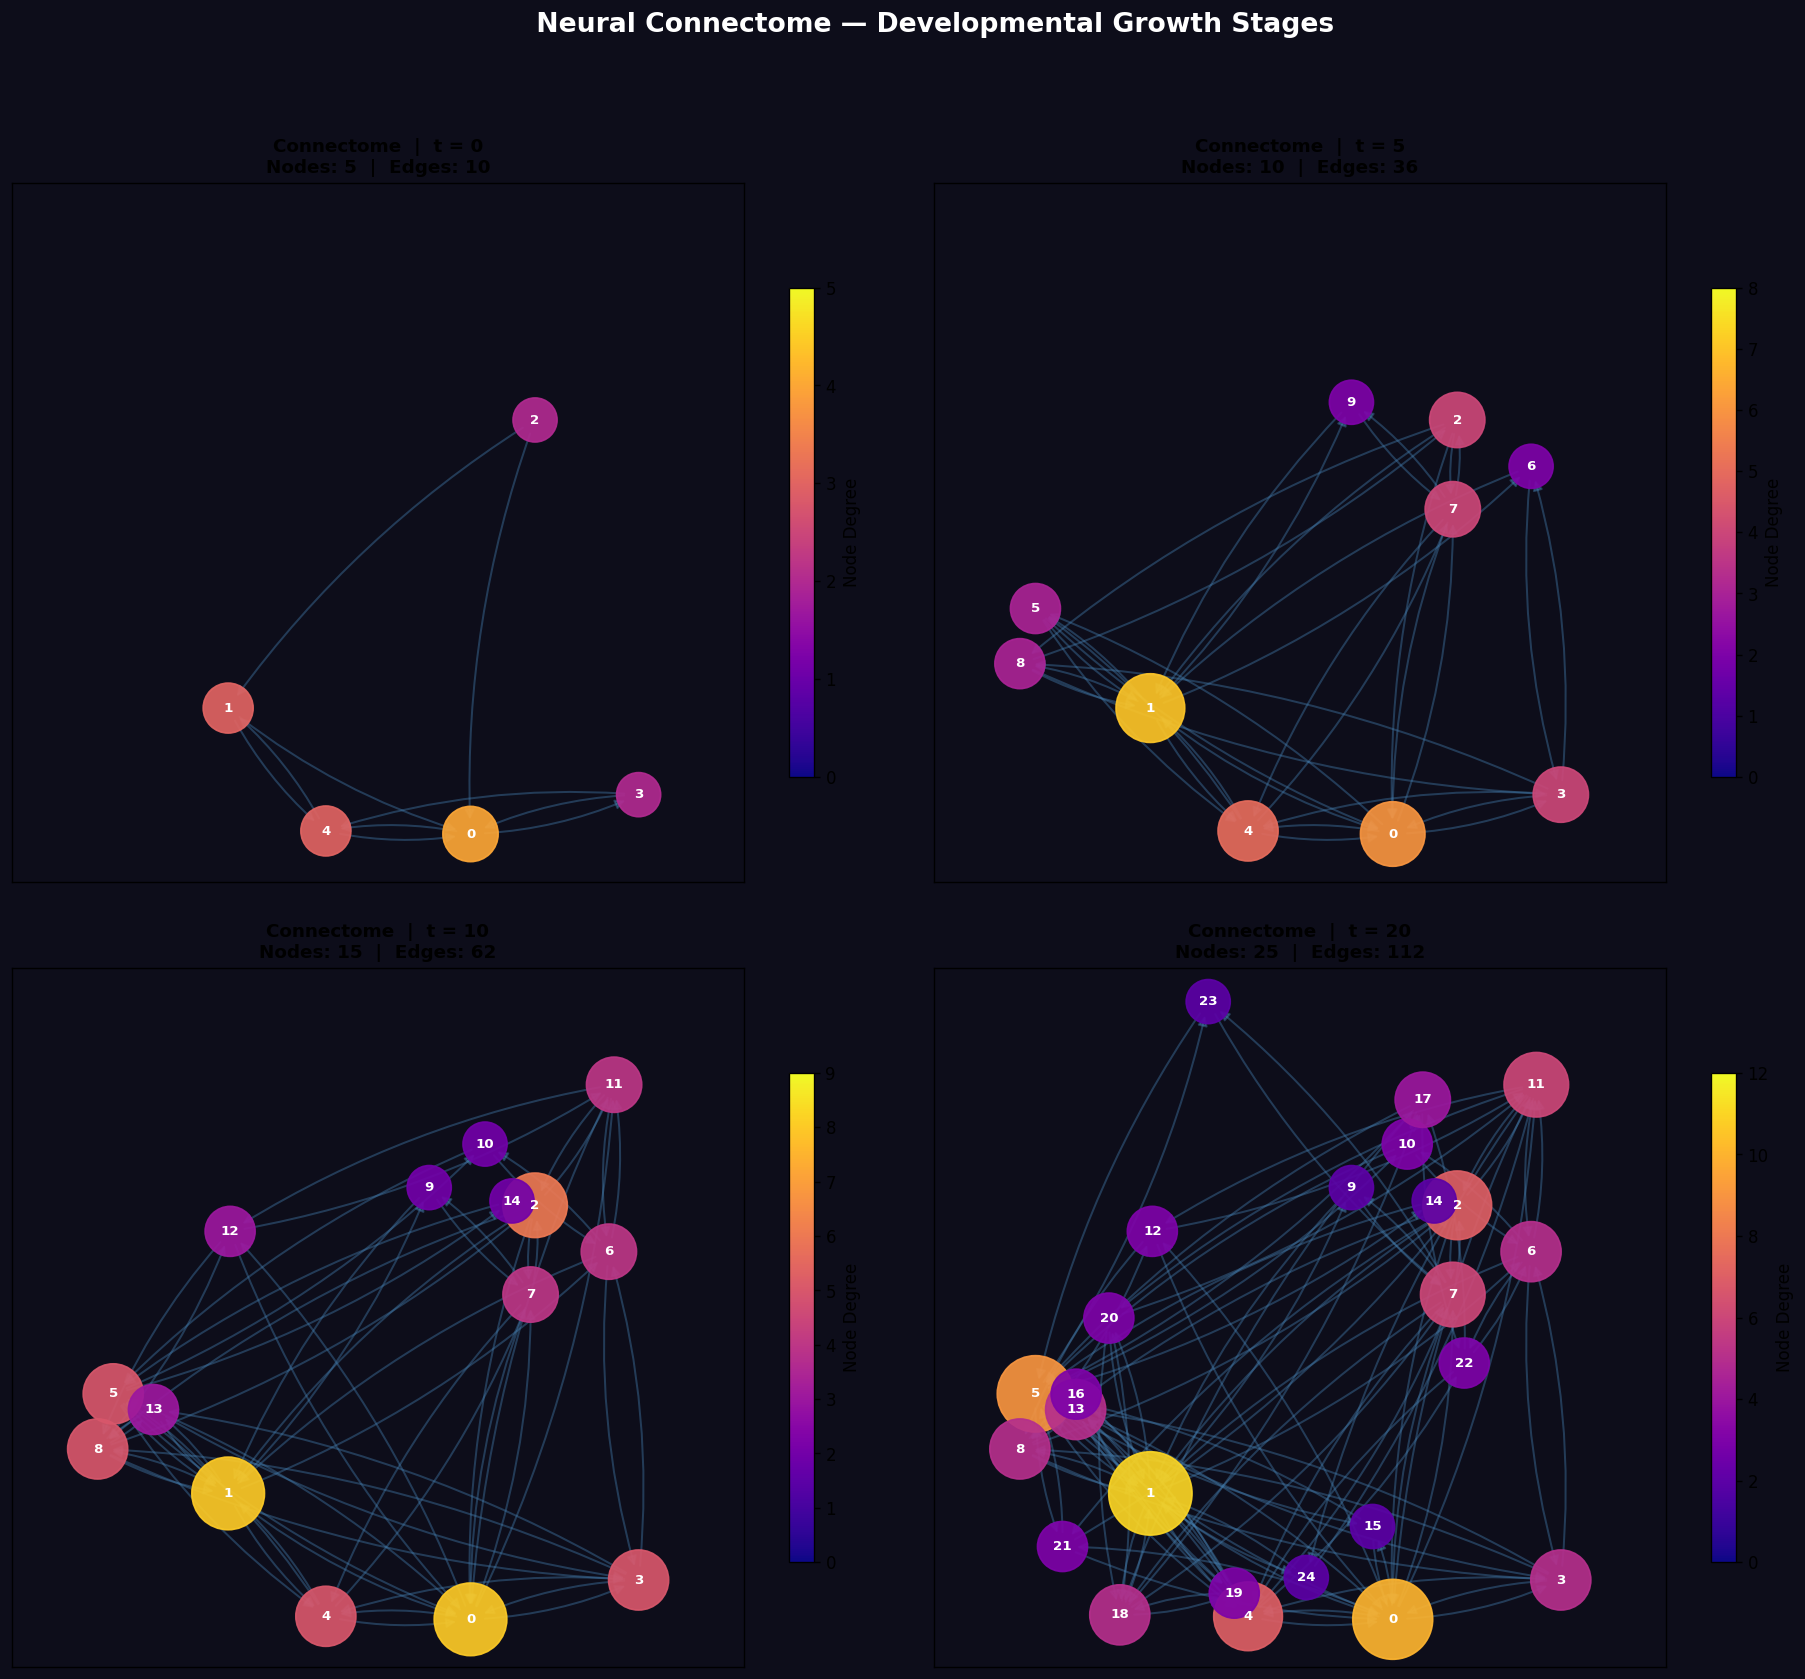

 Saved → /content/connectome_growth_stages.png


In [18]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))
fig.patch.set_facecolor('#0d0d1a')
fig.suptitle(
    " Neural Connectome — Developmental Growth Stages",
    fontsize=16, fontweight='bold', color='white', y=1.01
)

axes_flat = axes.flatten()

for idx, t in enumerate(SNAPSHOT_STEPS):
    ax  = axes_flat[idx]
    G_s = graph_snapshots[t]
    draw_connectome(G_s, ax, title="Connectome", timestep=t)

plt.tight_layout(pad=2.5)
plt.savefig('/content/connectome_growth_stages.png',
            dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print(" Saved → /content/connectome_growth_stages.png")

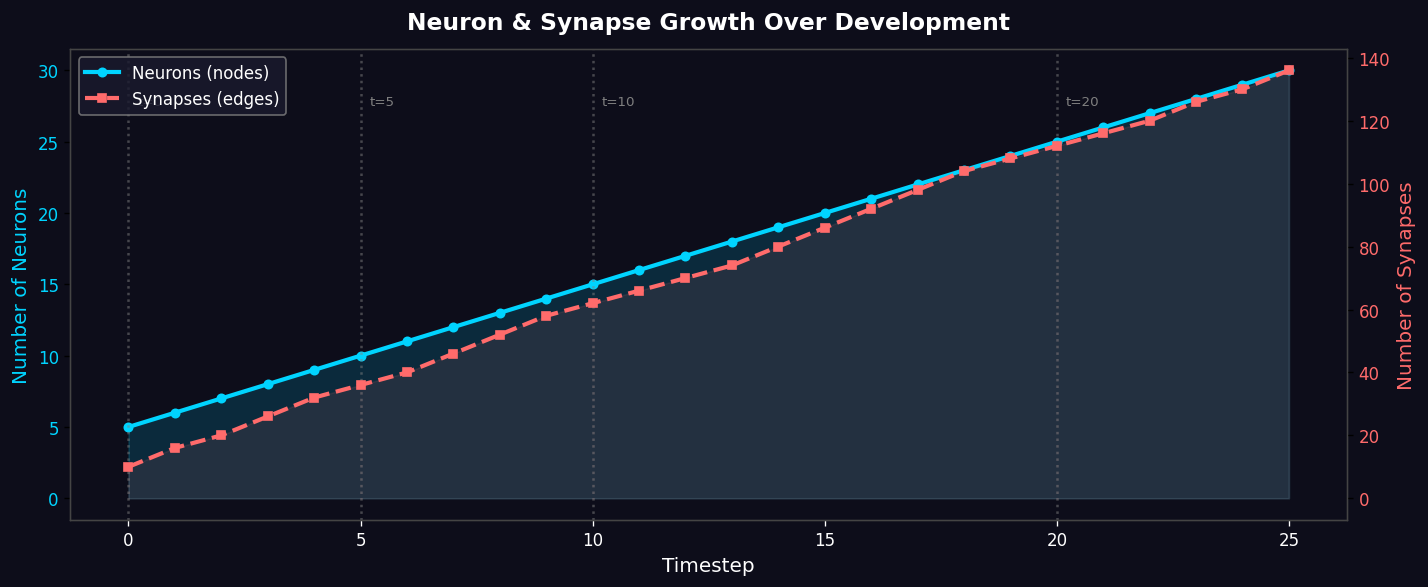

 Saved → /content/growth_nodes_edges.png


In [19]:
timesteps   = sorted(metrics_log.keys())
nodes_list  = [metrics_log[t]['n_nodes'] for t in timesteps]
edges_list  = [metrics_log[t]['n_edges'] for t in timesteps]

fig, ax1 = plt.subplots(figsize=(12, 5))
fig.patch.set_facecolor('#0d0d1a')
ax1.set_facecolor('#0d0d1a')


color_nodes = '#00d4ff'
ax1.plot(timesteps, nodes_list,
         color=color_nodes, linewidth=2.5,
         marker='o', markersize=5, label='Neurons (nodes)')
ax1.fill_between(timesteps, nodes_list,
                 alpha=0.15, color=color_nodes)
ax1.set_xlabel('Timestep', color='white', fontsize=12)
ax1.set_ylabel('Number of Neurons', color=color_nodes, fontsize=12)
ax1.tick_params(axis='y', labelcolor=color_nodes)
ax1.tick_params(axis='x', colors='white')


ax2         = ax1.twinx()
color_edges = '#ff6b6b'
ax2.plot(timesteps, edges_list,
         color=color_edges, linewidth=2.5,
         marker='s', markersize=5,
         linestyle='--', label='Synapses (edges)')
ax2.fill_between(timesteps, edges_list,
                 alpha=0.10, color=color_edges)
ax2.set_ylabel('Number of Synapses', color=color_edges, fontsize=12)
ax2.tick_params(axis='y', labelcolor=color_edges)
ax2.set_facecolor('#0d0d1a')


for t in SNAPSHOT_STEPS:
    ax1.axvline(x=t, color='gray', linestyle=':', alpha=0.5)
    ax1.text(t + 0.2, max(nodes_list) * 0.92,
             f't={t}', color='gray', fontsize=8)


lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2,
           loc='upper left',
           facecolor='#1a1a2e', edgecolor='gray',
           labelcolor='white', fontsize=10)

ax1.set_title('Neuron & Synapse Growth Over Development',
              color='white', fontsize=14, fontweight='bold', pad=12)

for spine in ax1.spines.values():
    spine.set_edgecolor('#444')
for spine in ax2.spines.values():
    spine.set_edgecolor('#444')

plt.tight_layout()
plt.savefig('/content/growth_nodes_edges.png',
            dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print(" Saved → /content/growth_nodes_edges.png")

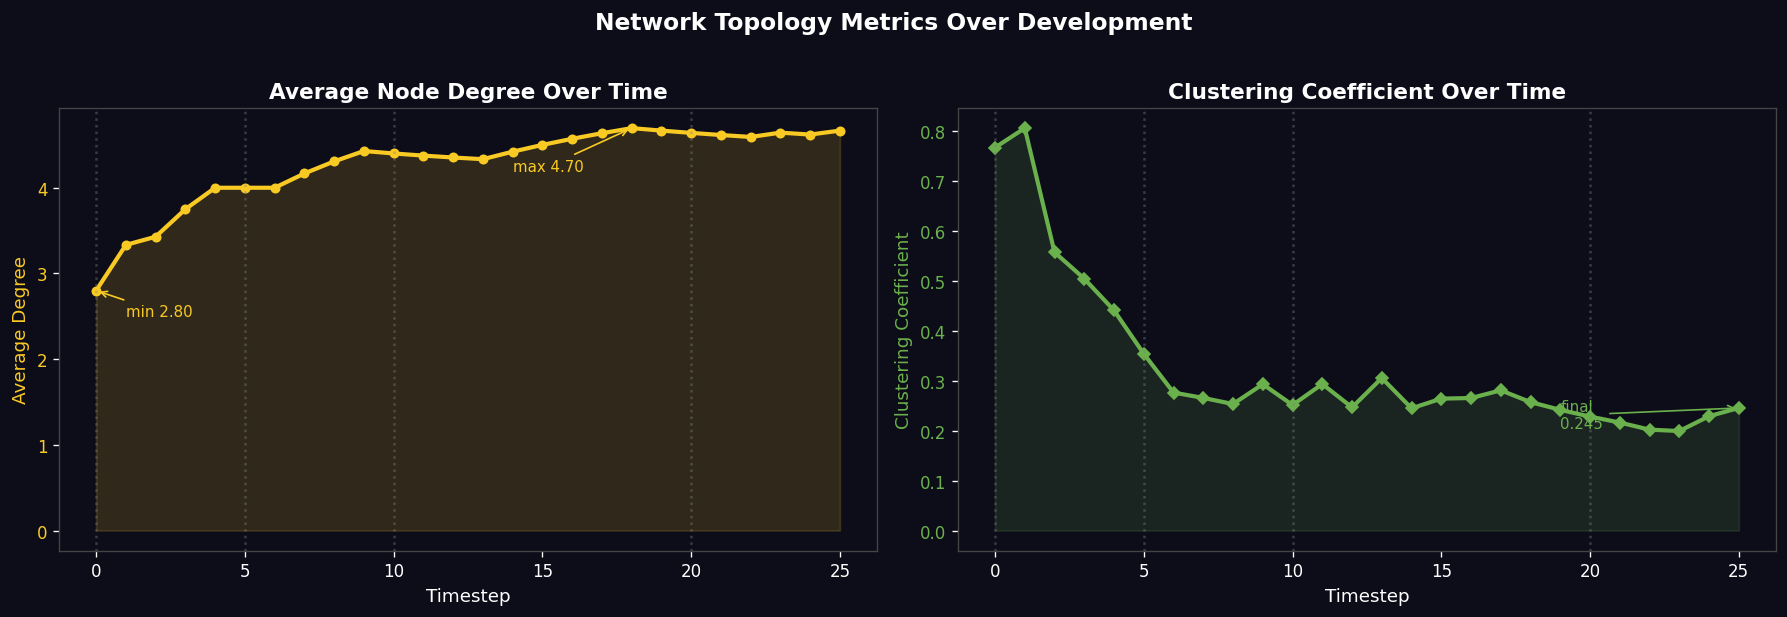

 Saved → /content/topology_metrics.png


In [20]:
avgdeg_list = [metrics_log[t]['avg_deg']    for t in timesteps]
clust_list  = [metrics_log[t]['clustering'] for t in timesteps]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
fig.patch.set_facecolor('#0d0d1a')


ax1.set_facecolor('#0d0d1a')
color_deg = '#f9ca24'

ax1.plot(timesteps, avgdeg_list,
         color=color_deg, linewidth=2.5,
         marker='o', markersize=5)
ax1.fill_between(timesteps, avgdeg_list,
                 alpha=0.15, color=color_deg)


min_t   = timesteps[np.argmin(avgdeg_list)]
max_t   = timesteps[np.argmax(avgdeg_list)]
ax1.annotate(f"min {min(avgdeg_list):.2f}",
             xy=(min_t, min(avgdeg_list)),
             xytext=(min_t + 1, min(avgdeg_list) - 0.3),
             color=color_deg, fontsize=9,
             arrowprops=dict(arrowstyle='->', color=color_deg))
ax1.annotate(f"max {max(avgdeg_list):.2f}",
             xy=(max_t, max(avgdeg_list)),
             xytext=(max_t - 4, max(avgdeg_list) - 0.5),
             color=color_deg, fontsize=9,
             arrowprops=dict(arrowstyle='->', color=color_deg))

for t in SNAPSHOT_STEPS:
    ax1.axvline(x=t, color='gray', linestyle=':', alpha=0.4)

ax1.set_title('Average Node Degree Over Time',
              color='white', fontsize=13, fontweight='bold')
ax1.set_xlabel('Timestep', color='white', fontsize=11)
ax1.set_ylabel('Average Degree', color=color_deg, fontsize=11)
ax1.tick_params(colors='white')
ax1.tick_params(axis='y', labelcolor=color_deg)
for spine in ax1.spines.values():
    spine.set_edgecolor('#444')


ax2.set_facecolor('#0d0d1a')
color_cl = '#6ab04c'

ax2.plot(timesteps, clust_list,
         color=color_cl, linewidth=2.5,
         marker='D', markersize=5)
ax2.fill_between(timesteps, clust_list,
                 alpha=0.15, color=color_cl)


ax2.annotate(f"final\n{clust_list[-1]:.3f}",
             xy=(timesteps[-1], clust_list[-1]),
             xytext=(timesteps[-1] - 6, clust_list[-1] - 0.04),
             color=color_cl, fontsize=9,
             arrowprops=dict(arrowstyle='->', color=color_cl))

for t in SNAPSHOT_STEPS:
    ax2.axvline(x=t, color='gray', linestyle=':', alpha=0.4)

ax2.set_title('Clustering Coefficient Over Time',
              color='white', fontsize=13, fontweight='bold')
ax2.set_xlabel('Timestep', color='white', fontsize=11)
ax2.set_ylabel('Clustering Coefficient', color=color_cl, fontsize=11)
ax2.tick_params(colors='white')
ax2.tick_params(axis='y', labelcolor=color_cl)
for spine in ax2.spines.values():
    spine.set_edgecolor('#444')

plt.suptitle('Network Topology Metrics Over Development',
             color='white', fontsize=14,
             fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('/content/topology_metrics.png',
            dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print(" Saved → /content/topology_metrics.png")

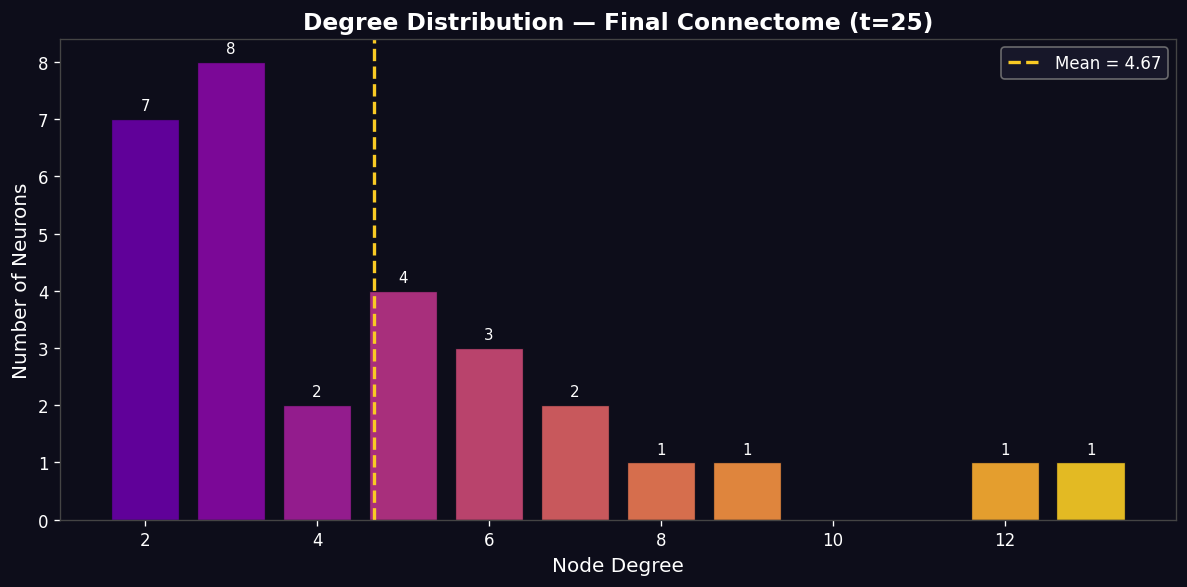

 Saved → /content/degree_distribution.png


In [21]:
G_und    = G.to_undirected()
degrees  = [d for _, d in G_und.degree()]
deg_vals = sorted(set(degrees))
deg_counts = [degrees.count(d) for d in deg_vals]

fig, ax = plt.subplots(figsize=(10, 5))
fig.patch.set_facecolor('#0d0d1a')
ax.set_facecolor('#0d0d1a')


bars = ax.bar(deg_vals, deg_counts,
              color=cm.plasma(np.linspace(0.2, 0.9, len(deg_vals))),
              edgecolor='#0d0d1a', linewidth=0.8, alpha=0.9)

for bar, count in zip(bars, deg_counts):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.1,
            str(count),
            ha='center', va='bottom',
            color='white', fontsize=9)


mean_deg = np.mean(degrees)
ax.axvline(x=mean_deg, color='#f9ca24',
           linestyle='--', linewidth=2, label=f'Mean = {mean_deg:.2f}')

ax.set_title(f'Degree Distribution — Final Connectome (t={TIMESTEPS})',
             color='white', fontsize=14, fontweight='bold')
ax.set_xlabel('Node Degree', color='white', fontsize=12)
ax.set_ylabel('Number of Neurons', color='white', fontsize=12)
ax.tick_params(colors='white')
ax.legend(facecolor='#1a1a2e', edgecolor='gray',
          labelcolor='white', fontsize=10)

for spine in ax.spines.values():
    spine.set_edgecolor('#444')

plt.tight_layout()
plt.savefig('/content/degree_distribution.png',
            dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print(" Saved → /content/degree_distribution.png")

/tmp/ipykernel_1058/3784376495.py:92: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  plt.savefig('/content/full_dashboard.png',
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


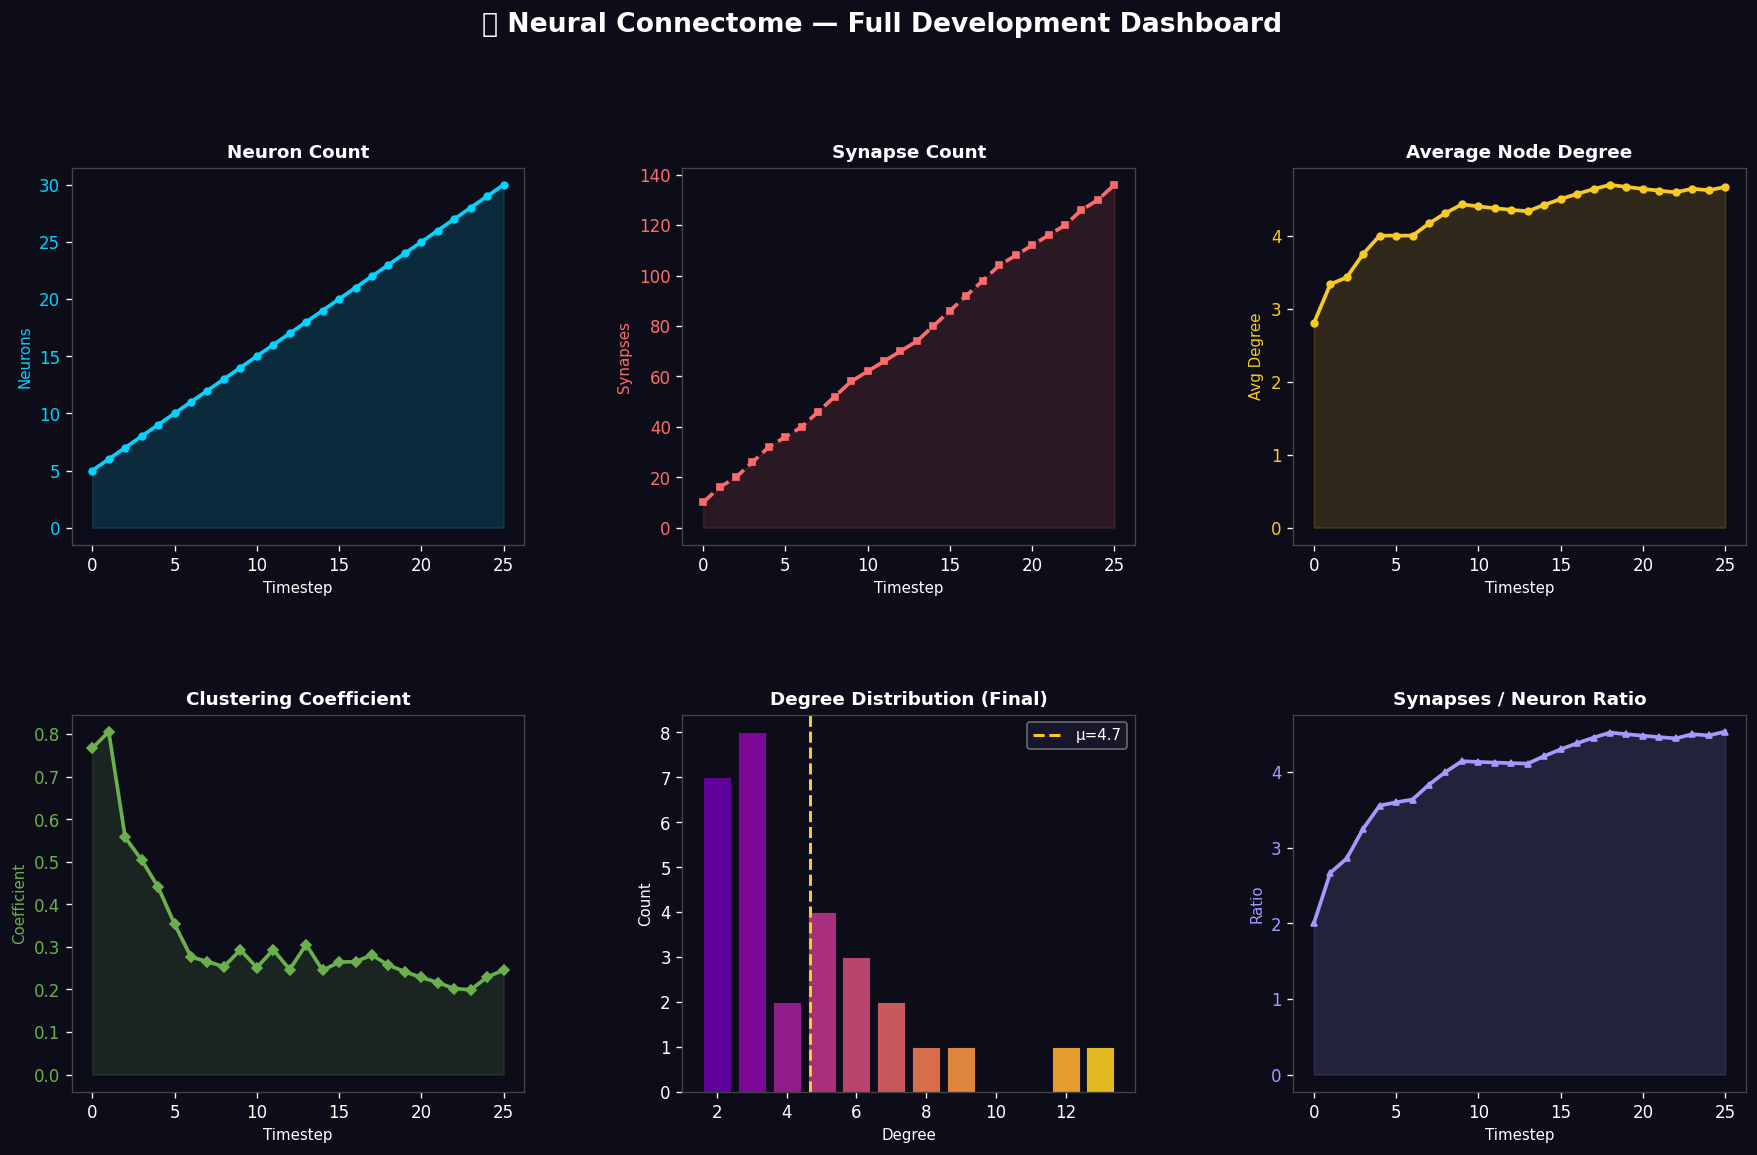

 Saved → /content/full_dashboard.png


In [22]:
fig = plt.figure(figsize=(18, 10))
fig.patch.set_facecolor('#0d0d1a')
fig.suptitle('🧠 Neural Connectome — Full Development Dashboard',
             fontsize=16, fontweight='bold',
             color='white', y=1.01)


gs = fig.add_gridspec(2, 3, hspace=0.45, wspace=0.35)

# ── Plot 1: Nodes growth ──────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor('#0d0d1a')
ax1.plot(timesteps, nodes_list,
         color='#00d4ff', linewidth=2.2, marker='o', markersize=4)
ax1.fill_between(timesteps, nodes_list, alpha=0.15, color='#00d4ff')
ax1.set_title('Neuron Count', color='white', fontsize=11, fontweight='bold')
ax1.set_xlabel('Timestep', color='white', fontsize=9)
ax1.set_ylabel('Neurons', color='#00d4ff', fontsize=9)
ax1.tick_params(colors='white'); ax1.tick_params(axis='y', labelcolor='#00d4ff')
for sp in ax1.spines.values(): sp.set_edgecolor('#444')

# ── Plot 2: Edges growth ──────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor('#0d0d1a')
ax2.plot(timesteps, edges_list,
         color='#ff6b6b', linewidth=2.2,
         marker='s', markersize=4, linestyle='--')
ax2.fill_between(timesteps, edges_list, alpha=0.12, color='#ff6b6b')
ax2.set_title('Synapse Count', color='white', fontsize=11, fontweight='bold')
ax2.set_xlabel('Timestep', color='white', fontsize=9)
ax2.set_ylabel('Synapses', color='#ff6b6b', fontsize=9)
ax2.tick_params(colors='white'); ax2.tick_params(axis='y', labelcolor='#ff6b6b')
for sp in ax2.spines.values(): sp.set_edgecolor('#444')

# ── Plot 3: Avg Degree ────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
ax3.set_facecolor('#0d0d1a')
ax3.plot(timesteps, avgdeg_list,
         color='#f9ca24', linewidth=2.2, marker='o', markersize=4)
ax3.fill_between(timesteps, avgdeg_list, alpha=0.15, color='#f9ca24')
ax3.set_title('Average Node Degree', color='white', fontsize=11, fontweight='bold')
ax3.set_xlabel('Timestep', color='white', fontsize=9)
ax3.set_ylabel('Avg Degree', color='#f9ca24', fontsize=9)
ax3.tick_params(colors='white'); ax3.tick_params(axis='y', labelcolor='#f9ca24')
for sp in ax3.spines.values(): sp.set_edgecolor('#444')

# ── Plot 4: Clustering Coefficient ───────────────────
ax4 = fig.add_subplot(gs[1, 0])
ax4.set_facecolor('#0d0d1a')
ax4.plot(timesteps, clust_list,
         color='#6ab04c', linewidth=2.2, marker='D', markersize=4)
ax4.fill_between(timesteps, clust_list, alpha=0.15, color='#6ab04c')
ax4.set_title('Clustering Coefficient', color='white', fontsize=11, fontweight='bold')
ax4.set_xlabel('Timestep', color='white', fontsize=9)
ax4.set_ylabel('Coefficient', color='#6ab04c', fontsize=9)
ax4.tick_params(colors='white'); ax4.tick_params(axis='y', labelcolor='#6ab04c')
for sp in ax4.spines.values(): sp.set_edgecolor('#444')

# ── Plot 5: Degree Distribution ───────────────────────
ax5 = fig.add_subplot(gs[1, 1])
ax5.set_facecolor('#0d0d1a')
ax5.bar(deg_vals, deg_counts,
        color=cm.plasma(np.linspace(0.2, 0.9, len(deg_vals))),
        edgecolor='#0d0d1a', linewidth=0.6, alpha=0.9)
ax5.axvline(x=mean_deg, color='#f9ca24',
            linestyle='--', linewidth=1.8,
            label=f'μ={mean_deg:.1f}')
ax5.set_title('Degree Distribution (Final)', color='white',
              fontsize=11, fontweight='bold')
ax5.set_xlabel('Degree', color='white', fontsize=9)
ax5.set_ylabel('Count', color='white', fontsize=9)
ax5.tick_params(colors='white')
ax5.legend(facecolor='#1a1a2e', edgecolor='gray',
           labelcolor='white', fontsize=9)
for sp in ax5.spines.values(): sp.set_edgecolor('#444')

# ── Plot 6: Edges/Nodes Ratio over time ───────────────
ax6 = fig.add_subplot(gs[1, 2])
ax6.set_facecolor('#0d0d1a')
ratio_list = [metrics_log[t]['n_edges'] / metrics_log[t]['n_nodes']
              for t in timesteps]
ax6.plot(timesteps, ratio_list,
         color='#a29bfe', linewidth=2.2, marker='^', markersize=4)
ax6.fill_between(timesteps, ratio_list, alpha=0.15, color='#a29bfe')
ax6.set_title('Synapses / Neuron Ratio', color='white',
              fontsize=11, fontweight='bold')
ax6.set_xlabel('Timestep', color='white', fontsize=9)
ax6.set_ylabel('Ratio', color='#a29bfe', fontsize=9)
ax6.tick_params(colors='white'); ax6.tick_params(axis='y', labelcolor='#a29bfe')
for sp in ax6.spines.values(): sp.set_edgecolor('#444')

plt.savefig('/content/full_dashboard.png',
            dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print(" Saved → /content/full_dashboard.png")

In [23]:
from torch_geometric.data import Data
from torch_geometric.nn   import GCNConv
import torch
import torch.nn.functional as F
from sklearn.decomposition import PCA
import matplotlib.pyplot    as plt
import matplotlib.cm        as cm
import numpy                as np

def networkx_to_pyg(G):
    """
    Convert a NetworkX DiGraph into a PyTorch Geometric Data object.

    Node features (per neuron):
        0 — normalized x position      (spatial)
        1 — normalized y position      (spatial)
        2 — normalized degree          (connectivity)
        3 — normalized in-degree       (incoming synapses)
        4 — normalized out-degree      (outgoing synapses)
        5 — clustering coefficient     (local topology)

    Returns:
        data  : torch_geometric.data.Data
        mapping : dict {original_node_id → contiguous_index}
    """
    # -- Build contiguous node index mapping --
    nodes   = sorted(G.nodes())
    mapping = {n: i for i, n in enumerate(nodes)}
    n_nodes = len(nodes)

    G_und   = G.to_undirected()

    # -- Build node feature matrix --
    features = []
    max_pos   = SPACE_SIZE
    max_deg   = max(dict(G_und.degree()).values()) + 1e-6

    for node in nodes:
        pos       = G.nodes[node]['pos']
        x_norm    = pos[0] / max_pos
        y_norm    = pos[1] / max_pos
        deg_norm  = G_und.degree(node)    / max_deg
        in_norm   = G.in_degree(node)     / max_deg
        out_norm  = G.out_degree(node)    / max_deg
        clust     = nx.clustering(G_und, node)

        features.append([x_norm, y_norm, deg_norm,
                          in_norm, out_norm, clust])

    x = torch.tensor(features, dtype=torch.float)

    # -- Build edge index tensor --
    edges      = list(G.edges())
    edge_index = torch.tensor(
        [[mapping[u] for u, v in edges],
         [mapping[v] for u, v in edges]],
        dtype=torch.long
    )

    # -- Build edge weights (inverse distance) --
    edge_weights = []
    for u, v in edges:
        pos_u = G.nodes[u]['pos']
        pos_v = G.nodes[v]['pos']
        dist  = euclidean_distance(pos_u, pos_v)
        edge_weights.append(1.0 / (dist + 1e-6))

    edge_attr = torch.tensor(edge_weights,
                              dtype=torch.float).unsqueeze(1)

    data = Data(x=x,
                edge_index=edge_index,
                edge_attr=edge_attr,
                num_nodes=n_nodes)

    return data, mapping


# -- Convert final graph --
pyg_data, node_mapping = networkx_to_pyg(G)
pyg_data = pyg_data.to(DEVICE)

print(" NetworkX → PyTorch Geometric conversion complete\n")
print(f"  Number of nodes     : {pyg_data.num_nodes}")
print(f"  Number of edges     : {pyg_data.num_edges}")
print(f"  Node feature shape  : {pyg_data.x.shape}   "
      f"(nodes × features)")
print(f"  Edge index shape    : {pyg_data.edge_index.shape}")
print(f"  Edge attr shape     : {pyg_data.edge_attr.shape}")
print(f"  Device              : {pyg_data.x.device}")
print(f"\n  Feature columns:")
feat_names = ['x_pos', 'y_pos', 'degree',
              'in_degree', 'out_degree', 'clustering']
for i, name in enumerate(feat_names):
    col = pyg_data.x[:, i]
    print(f"    [{i}] {name:<14} "
          f"min={col.min():.3f}  "
          f"max={col.max():.3f}  "
          f"mean={col.mean():.3f}")

 NetworkX → PyTorch Geometric conversion complete

  Number of nodes     : 30
  Number of edges     : 136
  Node feature shape  : torch.Size([30, 6])   (nodes × features)
  Edge index shape    : torch.Size([2, 136])
  Edge attr shape     : torch.Size([136, 1])
  Device              : cuda:0

  Feature columns:
    [0] x_pos          min=0.079  max=0.892  mean=0.509
    [1] y_pos          min=0.025  max=0.997  mean=0.426
    [2] degree         min=0.154  max=1.000  mean=0.359
    [3] in_degree      min=0.154  max=1.000  mean=0.349
    [4] out_degree     min=0.154  max=0.846  mean=0.349
    [5] clustering     min=0.000  max=1.000  mean=0.245


In [24]:
class ConnectomeGCN(torch.nn.Module):
    """
    Two-layer Graph Convolutional Network for computing
    neuron embeddings from the connectome graph.

    Architecture:
        Input  (6 features)
            ↓
        GCNConv Layer 1  →  ReLU  →  Dropout
            ↓
        GCNConv Layer 2  →  ReLU
            ↓
        GCNConv Layer 3  →  Output embeddings (16-dim)

    The GCN aggregates information from each neuron's
    neighbourhood, encoding both local topology and
    spatial structure into fixed-size embedding vectors.
    """

    def __init__(self,
                 in_channels,
                 hidden_channels=32,
                 out_channels=16,
                 dropout=0.3):
        super(ConnectomeGCN, self).__init__()

        self.dropout = dropout

        # Layer 1: input → hidden
        self.conv1 = GCNConv(in_channels, hidden_channels)

        # Layer 2: hidden → hidden
        self.conv2 = GCNConv(hidden_channels, hidden_channels)

        # Layer 3: hidden → output embeddings
        self.conv3 = GCNConv(hidden_channels, out_channels)

        # Batch norm for stable training
        self.bn1 = torch.nn.BatchNorm1d(hidden_channels)
        self.bn2 = torch.nn.BatchNorm1d(hidden_channels)

    def forward(self, x, edge_index):
        # -- Layer 1 --
        h = self.conv1(x, edge_index)
        h = self.bn1(h)
        h = F.relu(h)
        h = F.dropout(h, p=self.dropout, training=self.training)

        # -- Layer 2 --
        h = self.conv2(h, edge_index)
        h = self.bn2(h)
        h = F.relu(h)
        h = F.dropout(h, p=self.dropout, training=self.training)

        # -- Layer 3: output embeddings --
        h = self.conv3(h, edge_index)
        h = F.relu(h)

        return h


# -- Instantiate model --
IN_CHANNELS     = pyg_data.x.shape[1]   # 6 node features
HIDDEN_CHANNELS = 32
OUT_CHANNELS    = 16                     # Embedding dimension

model = ConnectomeGCN(
    in_channels    = IN_CHANNELS,
    hidden_channels= HIDDEN_CHANNELS,
    out_channels   = OUT_CHANNELS
).to(DEVICE)

print(" GNN model defined\n")
print(model)
print(f"\n  Input features  : {IN_CHANNELS}")
print(f"  Hidden dim      : {HIDDEN_CHANNELS}")
print(f"  Embedding dim   : {OUT_CHANNELS}")

# -- Parameter count --
total_params = sum(p.numel() for p in model.parameters())
print(f"  Total params    : {total_params:,}")

 GNN model defined

ConnectomeGCN(
  (conv1): GCNConv(6, 32)
  (conv2): GCNConv(32, 32)
  (conv3): GCNConv(32, 16)
  (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
)

  Input features  : 6
  Hidden dim      : 32
  Embedding dim   : 16
  Total params    : 1,936


In [25]:
def adjacency_reconstruction_loss(embeddings, edge_index, num_nodes):
    """
    Self-supervised loss: reconstruct the adjacency structure
    from embeddings using dot-product similarity.

    Connected pairs  → high similarity (target = 1)
    Random neg pairs → low similarity  (target = 0)

    This trains the GCN to encode structural information
    without requiring external labels.
    """
    # -- Positive pairs (existing edges) --
    src, dst     = edge_index
    pos_scores   = (embeddings[src] * embeddings[dst]).sum(dim=1)
    pos_loss     = F.binary_cross_entropy_with_logits(
        pos_scores,
        torch.ones(pos_scores.size(0), device=DEVICE)
    )

    # -- Negative pairs (random non-edges) --
    n_neg        = edge_index.size(1)
    neg_src      = torch.randint(0, num_nodes, (n_neg,), device=DEVICE)
    neg_dst      = torch.randint(0, num_nodes, (n_neg,), device=DEVICE)
    neg_scores   = (embeddings[neg_src] * embeddings[neg_dst]).sum(dim=1)
    neg_loss     = F.binary_cross_entropy_with_logits(
        neg_scores,
        torch.zeros(neg_scores.size(0), device=DEVICE)
    )

    return (pos_loss + neg_loss) / 2


# -- Training setup --
optimizer  = torch.optim.Adam(model.parameters(),
                               lr=0.01, weight_decay=5e-4)
scheduler  = torch.optim.lr_scheduler.StepLR(
                 optimizer, step_size=50, gamma=0.5)

EPOCHS     = 200
loss_log   = []

print("🔧 Training GCN on connectome graph...\n")
print(f"{'Epoch':>8} │ {'Loss':>10} │ {'LR':>10}")
print("─" * 34)

model.train()
for epoch in range(1, EPOCHS + 1):
    optimizer.zero_grad()

    embeddings = model(pyg_data.x, pyg_data.edge_index)

    loss       = adjacency_reconstruction_loss(
                     embeddings,
                     pyg_data.edge_index,
                     pyg_data.num_nodes
                 )
    loss.backward()
    optimizer.step()
    scheduler.step()

    loss_log.append(loss.item())

    if epoch % 40 == 0 or epoch == 1:
        lr = optimizer.param_groups[0]['lr']
        print(f"  {epoch:>6} │ {loss.item():>10.4f} │ {lr:>10.6f}")

print("\n Training complete!")
print(f"  Final loss : {loss_log[-1]:.4f}")
print(f"  Best loss  : {min(loss_log):.4f} "
      f"@ epoch {loss_log.index(min(loss_log)) + 1}")

🔧 Training GCN on connectome graph...

   Epoch │       Loss │         LR
──────────────────────────────────
       1 │     0.7964 │   0.010000
      40 │     0.6938 │   0.010000
      80 │     0.6398 │   0.005000
     120 │     0.6669 │   0.002500
     160 │     0.6501 │   0.001250
     200 │     0.6713 │   0.000625

 Training complete!
  Final loss : 0.6713
  Best loss  : 0.6274 @ epoch 179


In [26]:
model.eval()
with torch.no_grad():
    embeddings = model(pyg_data.x, pyg_data.edge_index)

embeddings_np = embeddings.cpu().numpy()

# -- Degree array for coloring --
G_und      = G.to_undirected()
nodes_list_sorted = sorted(G.nodes())
degrees_arr       = np.array([G_und.degree(n)
                               for n in nodes_list_sorted])

print(" Node embeddings extracted\n")
print(f"  Embedding matrix shape : {embeddings_np.shape}")
print(f"  (neurons × embedding_dim = "
      f"{embeddings_np.shape[0]} × {embeddings_np.shape[1]})\n")
print(f"  Embedding stats:")
print(f"    Mean : {embeddings_np.mean():.4f}")
print(f"    Std  : {embeddings_np.std():.4f}")
print(f"    Min  : {embeddings_np.min():.4f}")
print(f"    Max  : {embeddings_np.max():.4f}")

# -- Print sample embeddings for top-3 hub neurons --
top_hubs = sorted(range(len(degrees_arr)),
                  key=lambda i: degrees_arr[i],
                  reverse=True)[:3]

print(f"\n  Sample embeddings (top hub neurons):")
print(f"  {'Neuron':<10} {'Degree':<10} "
      f"{'Embedding (first 6 dims)':>30}")
print("  " + "-" * 58)
for idx in top_hubs:
    node   = nodes_list_sorted[idx]
    deg    = degrees_arr[idx]
    emb_preview = embeddings_np[idx, :6]
    print(f"  {node:<10} {deg:<10} "
          f"{np.array2string(emb_preview, precision=3, suppress_small=True)}")

 Node embeddings extracted

  Embedding matrix shape : (30, 16)
  (neurons × embedding_dim = 30 × 16)

  Embedding stats:
    Mean : 0.0529
    Std  : 0.1942
    Min  : 0.0000
    Max  : 1.3804

  Sample embeddings (top hub neurons):
  Neuron     Degree           Embedding (first 6 dims)
  ----------------------------------------------------------
  0          13         [0. 0. 0. 0. 0. 0.]
  1          12         [0. 0. 0. 0. 0. 0.]
  5          9          [0. 0. 0. 0. 0. 0.]


/tmp/ipykernel_1058/1374490079.py:93: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_1058/1374490079.py:94: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  plt.savefig('/content/gcn_embeddings_pca.png',
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129504 (\N{BRAIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


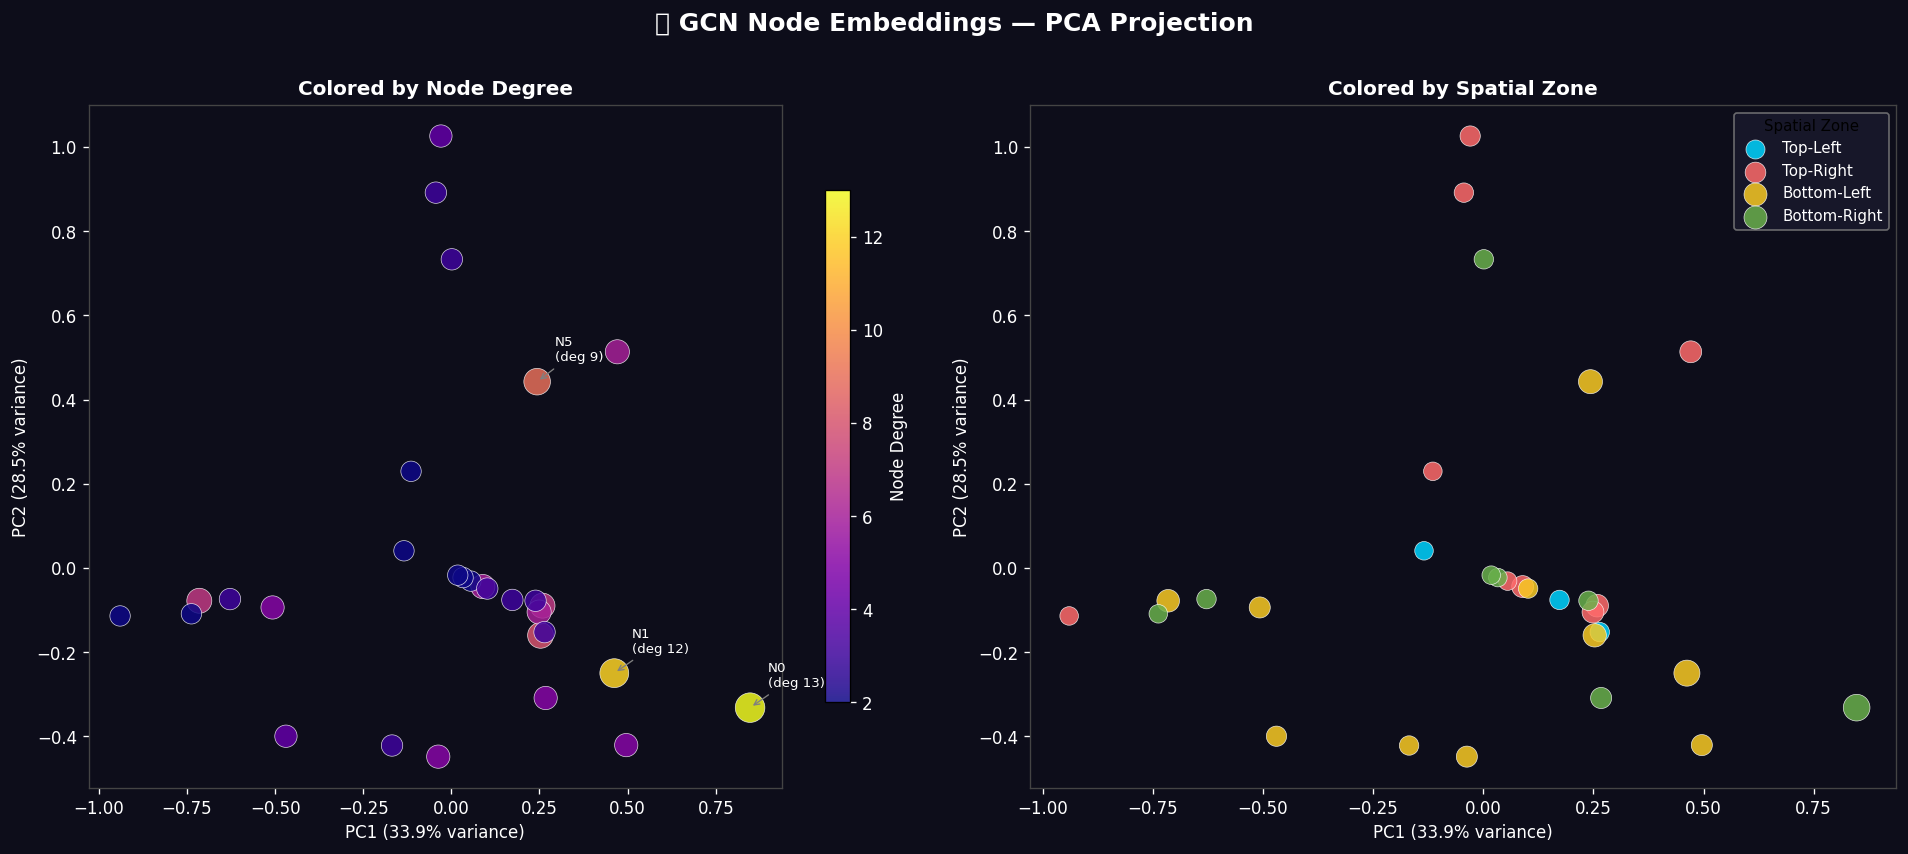

✅ Saved → /content/gcn_embeddings_pca.png


In [27]:
pca        = PCA(n_components=2, random_state=SEED)
emb_2d     = pca.fit_transform(embeddings_np)

explained  = pca.explained_variance_ratio_

fig, axes  = plt.subplots(1, 2, figsize=(16, 7))
fig.patch.set_facecolor('#0d0d1a')
fig.suptitle('🧠 GCN Node Embeddings — PCA Projection',
             fontsize=15, fontweight='bold',
             color='white', y=1.01)

# ---------- LEFT: Colored by Degree ----------
ax1   = axes[0]
ax1.set_facecolor('#0d0d1a')

sc1   = ax1.scatter(emb_2d[:, 0], emb_2d[:, 1],
                    c=degrees_arr,
                    cmap='plasma',
                    s=120 + degrees_arr * 15,
                    alpha=0.85,
                    edgecolors='white',
                    linewidths=0.4)

# Annotate top hub neurons
for idx in top_hubs:
    node = nodes_list_sorted[idx]
    ax1.annotate(f'N{node}\n(deg {degrees_arr[idx]})',
                 xy=(emb_2d[idx, 0], emb_2d[idx, 1]),
                 xytext=(emb_2d[idx, 0] + 0.05,
                         emb_2d[idx, 1] + 0.05),
                 color='white', fontsize=8,
                 arrowprops=dict(arrowstyle='->',
                                 color='gray',
                                 lw=0.8))

cbar1 = plt.colorbar(sc1, ax=ax1, shrink=0.75)
cbar1.set_label('Node Degree', color='white', fontsize=10)
cbar1.ax.yaxis.set_tick_params(color='white')
plt.setp(cbar1.ax.yaxis.get_ticklabels(), color='white')

ax1.set_title('Colored by Node Degree',
              color='white', fontsize=12, fontweight='bold')
ax1.set_xlabel(f'PC1 ({explained[0]*100:.1f}% variance)',
               color='white', fontsize=10)
ax1.set_ylabel(f'PC2 ({explained[1]*100:.1f}% variance)',
               color='white', fontsize=10)
ax1.tick_params(colors='white')
for sp in ax1.spines.values():
    sp.set_edgecolor('#444')

# ---------- RIGHT: Colored by Spatial Zone ----------
ax2  = axes[1]
ax2.set_facecolor('#0d0d1a')

# Divide space into 4 quadrants as "spatial zones"
zones = []
for node in nodes_list_sorted:
    px, py = G.nodes[node]['pos']
    mid    = SPACE_SIZE / 2
    if   px < mid and py >= mid: zones.append(0)   # top-left
    elif px >= mid and py >= mid: zones.append(1)  # top-right
    elif px < mid and py < mid:  zones.append(2)   # bottom-left
    else:                         zones.append(3)  # bottom-right

zones      = np.array(zones)
zone_names = ['Top-Left', 'Top-Right', 'Bottom-Left', 'Bottom-Right']
zone_colors= ['#00d4ff', '#ff6b6b', '#f9ca24', '#6ab04c']

for z in range(4):
    mask = zones == z
    ax2.scatter(emb_2d[mask, 0], emb_2d[mask, 1],
                c=zone_colors[z],
                s=100 + degrees_arr[mask] * 12,
                alpha=0.85,
                edgecolors='white',
                linewidths=0.4,
                label=zone_names[z])

ax2.legend(facecolor='#1a1a2e', edgecolor='gray',
           labelcolor='white', fontsize=9,
           title='Spatial Zone',
           title_fontsize=9)
ax2.set_title('Colored by Spatial Zone',
              color='white', fontsize=12, fontweight='bold')
ax2.set_xlabel(f'PC1 ({explained[0]*100:.1f}% variance)',
               color='white', fontsize=10)
ax2.set_ylabel(f'PC2 ({explained[1]*100:.1f}% variance)',
               color='white', fontsize=10)
ax2.tick_params(colors='white')
for sp in ax2.spines.values():
    sp.set_edgecolor('#444')

plt.tight_layout()
plt.savefig('/content/gcn_embeddings_pca.png',
            dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print("✅ Saved → /content/gcn_embeddings_pca.png")

<>:73: SyntaxWarning: invalid escape sequence '\ '
<>:73: SyntaxWarning: invalid escape sequence '\ '
/tmp/ipykernel_1058/3994875407.py:73: SyntaxWarning: invalid escape sequence '\ '
  print("\ Phase 6 complete — GNN embeddings fully computed!")


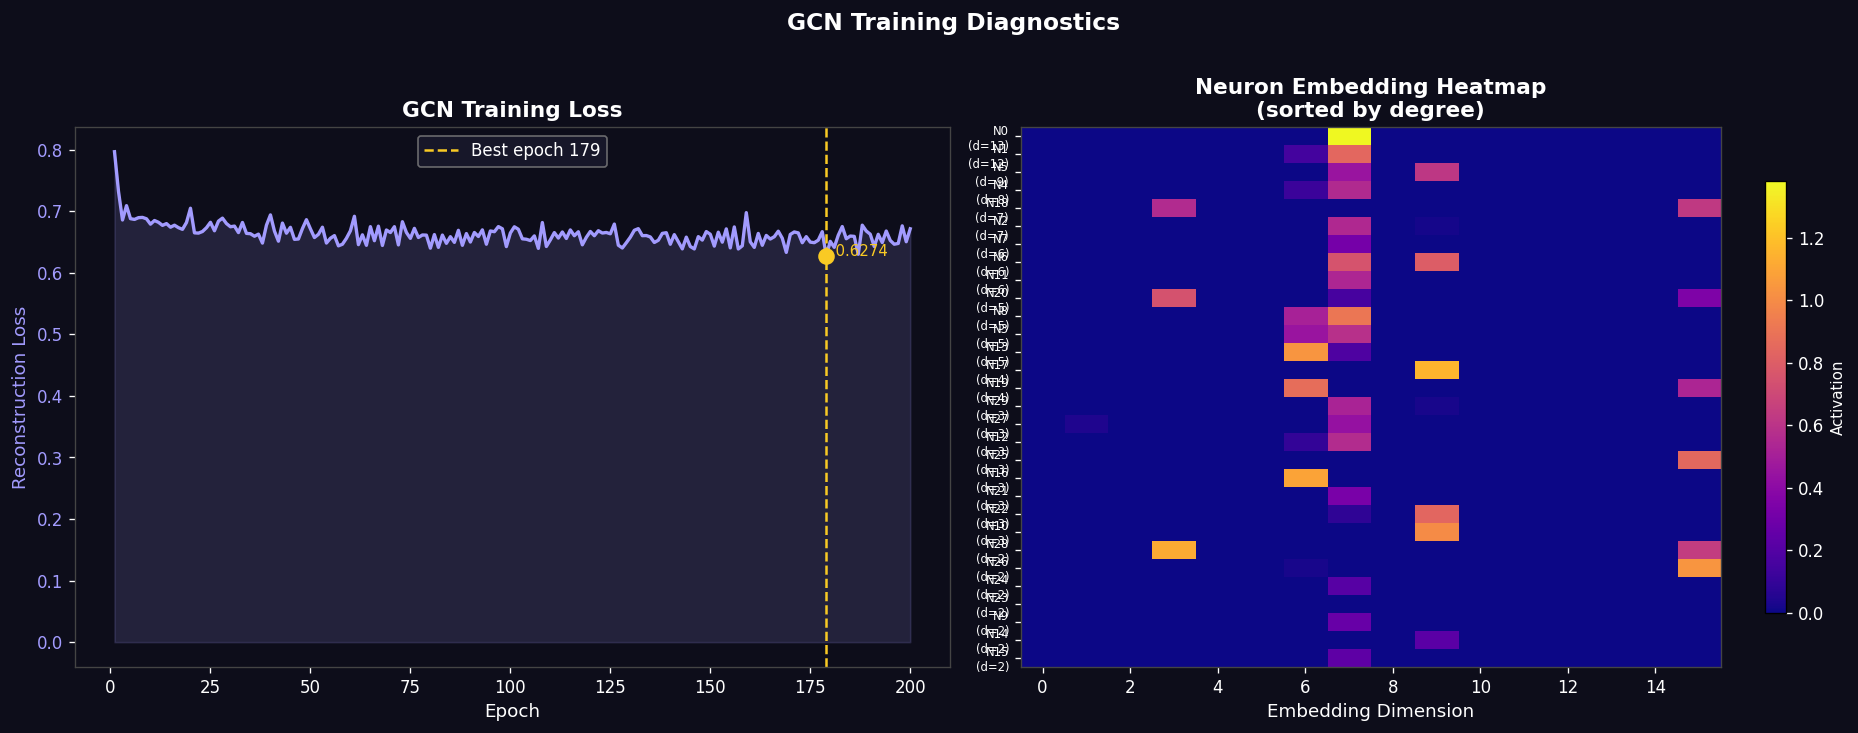

 Saved → /content/gcn_diagnostics.png
\ Phase 6 complete — GNN embeddings fully computed!


In [28]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.patch.set_facecolor('#0d0d1a')

# ---------- LEFT: Training Loss ----------
ax1.set_facecolor('#0d0d1a')
epochs_range = list(range(1, EPOCHS + 1))

ax1.plot(epochs_range, loss_log,
         color='#a29bfe', linewidth=2.0)
ax1.fill_between(epochs_range, loss_log,
                 alpha=0.15, color='#a29bfe')

# Mark best epoch
best_epoch = loss_log.index(min(loss_log)) + 1
best_loss  = min(loss_log)
ax1.axvline(x=best_epoch, color='#f9ca24',
            linestyle='--', linewidth=1.5,
            label=f'Best epoch {best_epoch}')
ax1.scatter([best_epoch], [best_loss],
            color='#f9ca24', s=80, zorder=5)
ax1.annotate(f'  {best_loss:.4f}',
             xy=(best_epoch, best_loss),
             color='#f9ca24', fontsize=9)

ax1.set_title('GCN Training Loss',
              color='white', fontsize=13, fontweight='bold')
ax1.set_xlabel('Epoch', color='white', fontsize=11)
ax1.set_ylabel('Reconstruction Loss', color='#a29bfe', fontsize=11)
ax1.tick_params(colors='white')
ax1.tick_params(axis='y', labelcolor='#a29bfe')
ax1.legend(facecolor='#1a1a2e', edgecolor='gray',
           labelcolor='white', fontsize=10)
for sp in ax1.spines.values():
    sp.set_edgecolor('#444')

# ---------- RIGHT: Embedding Heatmap ----------
ax2.set_facecolor('#0d0d1a')

# Sort neurons by degree for readable heatmap
sort_idx     = np.argsort(degrees_arr)[::-1]
emb_sorted   = embeddings_np[sort_idx]
labels_sorted= [f"N{nodes_list_sorted[i]}\n(d={degrees_arr[i]})"
                for i in sort_idx]

im = ax2.imshow(emb_sorted,
                aspect='auto',
                cmap='plasma',
                interpolation='nearest')

ax2.set_yticks(range(len(labels_sorted)))
ax2.set_yticklabels(labels_sorted, fontsize=7, color='white')
ax2.set_xlabel('Embedding Dimension', color='white', fontsize=11)
ax2.set_title('Neuron Embedding Heatmap\n(sorted by degree)',
              color='white', fontsize=13, fontweight='bold')
ax2.tick_params(colors='white')
for sp in ax2.spines.values():
    sp.set_edgecolor('#444')

cbar = plt.colorbar(im, ax=ax2, shrink=0.8)
cbar.set_label('Activation', color='white', fontsize=9)
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white')

plt.suptitle('GCN Training Diagnostics',
             color='white', fontsize=14,
             fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/content/gcn_diagnostics.png',
            dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print(" Saved → /content/gcn_diagnostics.png")
print("\ Phase 6 complete — GNN embeddings fully computed!")

In [29]:
print("\n")
print("╔" + "═" * 68 + "╗")
print("║" + "    NEURAL CONNECTOME GROWTH SIMULATION — FINAL REPORT".center(68) + "║")
print("╠" + "═" * 68 + "╣")

# -- Section 1: Simulation Config --
print("║" + "  SIMULATION CONFIGURATION".ljust(68) + "║")
print("╠" + "─" * 68 + "╣")
config_rows = [
    ("Initial neurons",        str(INITIAL_NEURONS)),
    ("Total timesteps",        str(TIMESTEPS)),
    ("Connections per step",   f"{CONNECTIONS_PER_STEP}–{MAX_CONNECTIONS}"),
    ("Spatial field size",     f"{SPACE_SIZE} × {SPACE_SIZE}"),
    ("Attachment weight α",    str(ALPHA)),
    ("Proximity weight β",     str(BETA)),
    ("GCN embedding dim",      str(OUT_CHANNELS)),
    ("GCN training epochs",    str(EPOCHS)),
    ("Device",                 str(DEVICE)),
    ("Random seed",            str(SEED)),
]
for label, value in config_rows:
    print("║" + f"    {label:<30} {value:<34}" + "║")

print("╠" + "═" * 68 + "╣")

# -- Section 2: Growth Summary --
print("║" + "  CONNECTOME GROWTH SUMMARY".ljust(68) + "║")
print("╠" + "─" * 68 + "╣")

t_start  = 0
t_end    = TIMESTEPS
m_start  = metrics_log[t_start]
m_end    = metrics_log[t_end]

growth_rows = [
    ("Neurons",            m_start['n_nodes'],   m_end['n_nodes'],
     f"+{m_end['n_nodes'] - m_start['n_nodes']}"),
    ("Synapses",           m_start['n_edges'],   m_end['n_edges'],
     f"+{m_end['n_edges'] - m_start['n_edges']}"),
    ("Avg node degree",    m_start['avg_deg'],   m_end['avg_deg'],
     f"+{round(m_end['avg_deg'] - m_start['avg_deg'], 3)}"),
    ("Clustering coeff",   m_start['clustering'],m_end['clustering'],
     f"+{round(m_end['clustering'] - m_start['clustering'], 4)}"),
]

print("║" + f"    {'Metric':<22} {'t=0':>8} {'t=25':>8} {'Change':>12}   " + "║")
print("║" + f"    {'─'*22} {'─'*8} {'─'*8} {'─'*12}   " + "║")
for label, v_start, v_end, change in growth_rows:
    print("║" + f"    {label:<22} {str(v_start):>8} "
          f"{str(v_end):>8} {change:>12}   " + "║")

print("╠" + "═" * 68 + "╣")

# -- Section 3: Topology at Snapshot Steps --
print("║" + "  TOPOLOGY AT KEY TIMESTEPS".ljust(68) + "║")
print("╠" + "─" * 68 + "╣")
print("║" + f"    {'Step':>5}  {'Nodes':>6}  {'Edges':>6}  "
      f"{'AvgDeg':>8}  {'Clustering':>12}  {'MaxDeg':>7}  " + "║")
print("║" + f"    {'─'*5}  {'─'*6}  {'─'*6}  "
      f"{'─'*8}  {'─'*12}  {'─'*7}  " + "║")
for t in SNAPSHOT_STEPS:
    m      = metrics_log[t]
    maxdeg = max(m['deg_dist'].keys()) if m['deg_dist'] else 0
    print("║" + f"    {t:>5}  {m['n_nodes']:>6}  {m['n_edges']:>6}  "
          f"{m['avg_deg']:>8}  {m['clustering']:>12}  {maxdeg:>7}  " + "║")

print("╠" + "═" * 68 + "╣")

# -- Section 4: Hub Neurons --
print("║" + "  TOP HUB NEURONS (HIGHEST CONNECTIVITY)".ljust(68) + "║")
print("╠" + "─" * 68 + "╣")
G_und    = G.to_undirected()
deg_dict = dict(G_und.degree())
top5     = sorted(deg_dict.items(), key=lambda x: x[1], reverse=True)[:5]
print("║" + f"    {'Neuron':<10} {'Degree':<10} "
      f"{'In-Deg':<10} {'Out-Deg':<10} {'Position':<18}" + "║")
print("║" + f"    {'─'*10} {'─'*10} {'─'*10} {'─'*10} {'─'*18}" + "║")
for node, deg in top5:
    pos     = G.nodes[node]['pos']
    in_d    = G.in_degree(node)
    out_d   = G.out_degree(node)
    print("║" + f"    {node:<10} {deg:<10} {in_d:<10} "
          f"{out_d:<10} {str(pos):<18}" + "║")

print("╠" + "═" * 68 + "╣")

# -- Section 5: GNN Summary --
print("║" + "  GNN EMBEDDING SUMMARY".ljust(68) + "║")
print("╠" + "─" * 68 + "╣")
gnn_rows = [
    ("Model architecture",    "3-layer GCN + BatchNorm + Dropout"),
    ("Node features",         "x_pos, y_pos, degree, in_deg, out_deg, clust"),
    ("Embedding dimensions",  str(OUT_CHANNELS)),
    ("Training objective",    "Adjacency reconstruction (self-supervised)"),
    ("Final training loss",   f"{loss_log[-1]:.4f}"),
    ("Best training loss",    f"{min(loss_log):.4f} "
                              f"@ epoch {loss_log.index(min(loss_log))+1}"),
    ("PCA variance (PC1+PC2)",f"{sum(pca.explained_variance_ratio_)*100:.1f}%"),
]
for label, value in gnn_rows:
    print("║" + f"    {label:<30} {value:<34}" + "║")

print("╚" + "═" * 68 + "╝")



╔════════════════════════════════════════════════════════════════════╗
║           NEURAL CONNECTOME GROWTH SIMULATION — FINAL REPORT       ║
╠════════════════════════════════════════════════════════════════════╣
║  SIMULATION CONFIGURATION                                          ║
╠────────────────────────────────────────────────────────────────────╣
║    Initial neurons                5                                 ║
║    Total timesteps                25                                ║
║    Connections per step           2–3                               ║
║    Spatial field size             10.0 × 10.0                       ║
║    Attachment weight α            0.5                               ║
║    Proximity weight β             0.5                               ║
║    GCN embedding dim              16                                ║
║    GCN training epochs            200                               ║
║    Device                         cuda                           

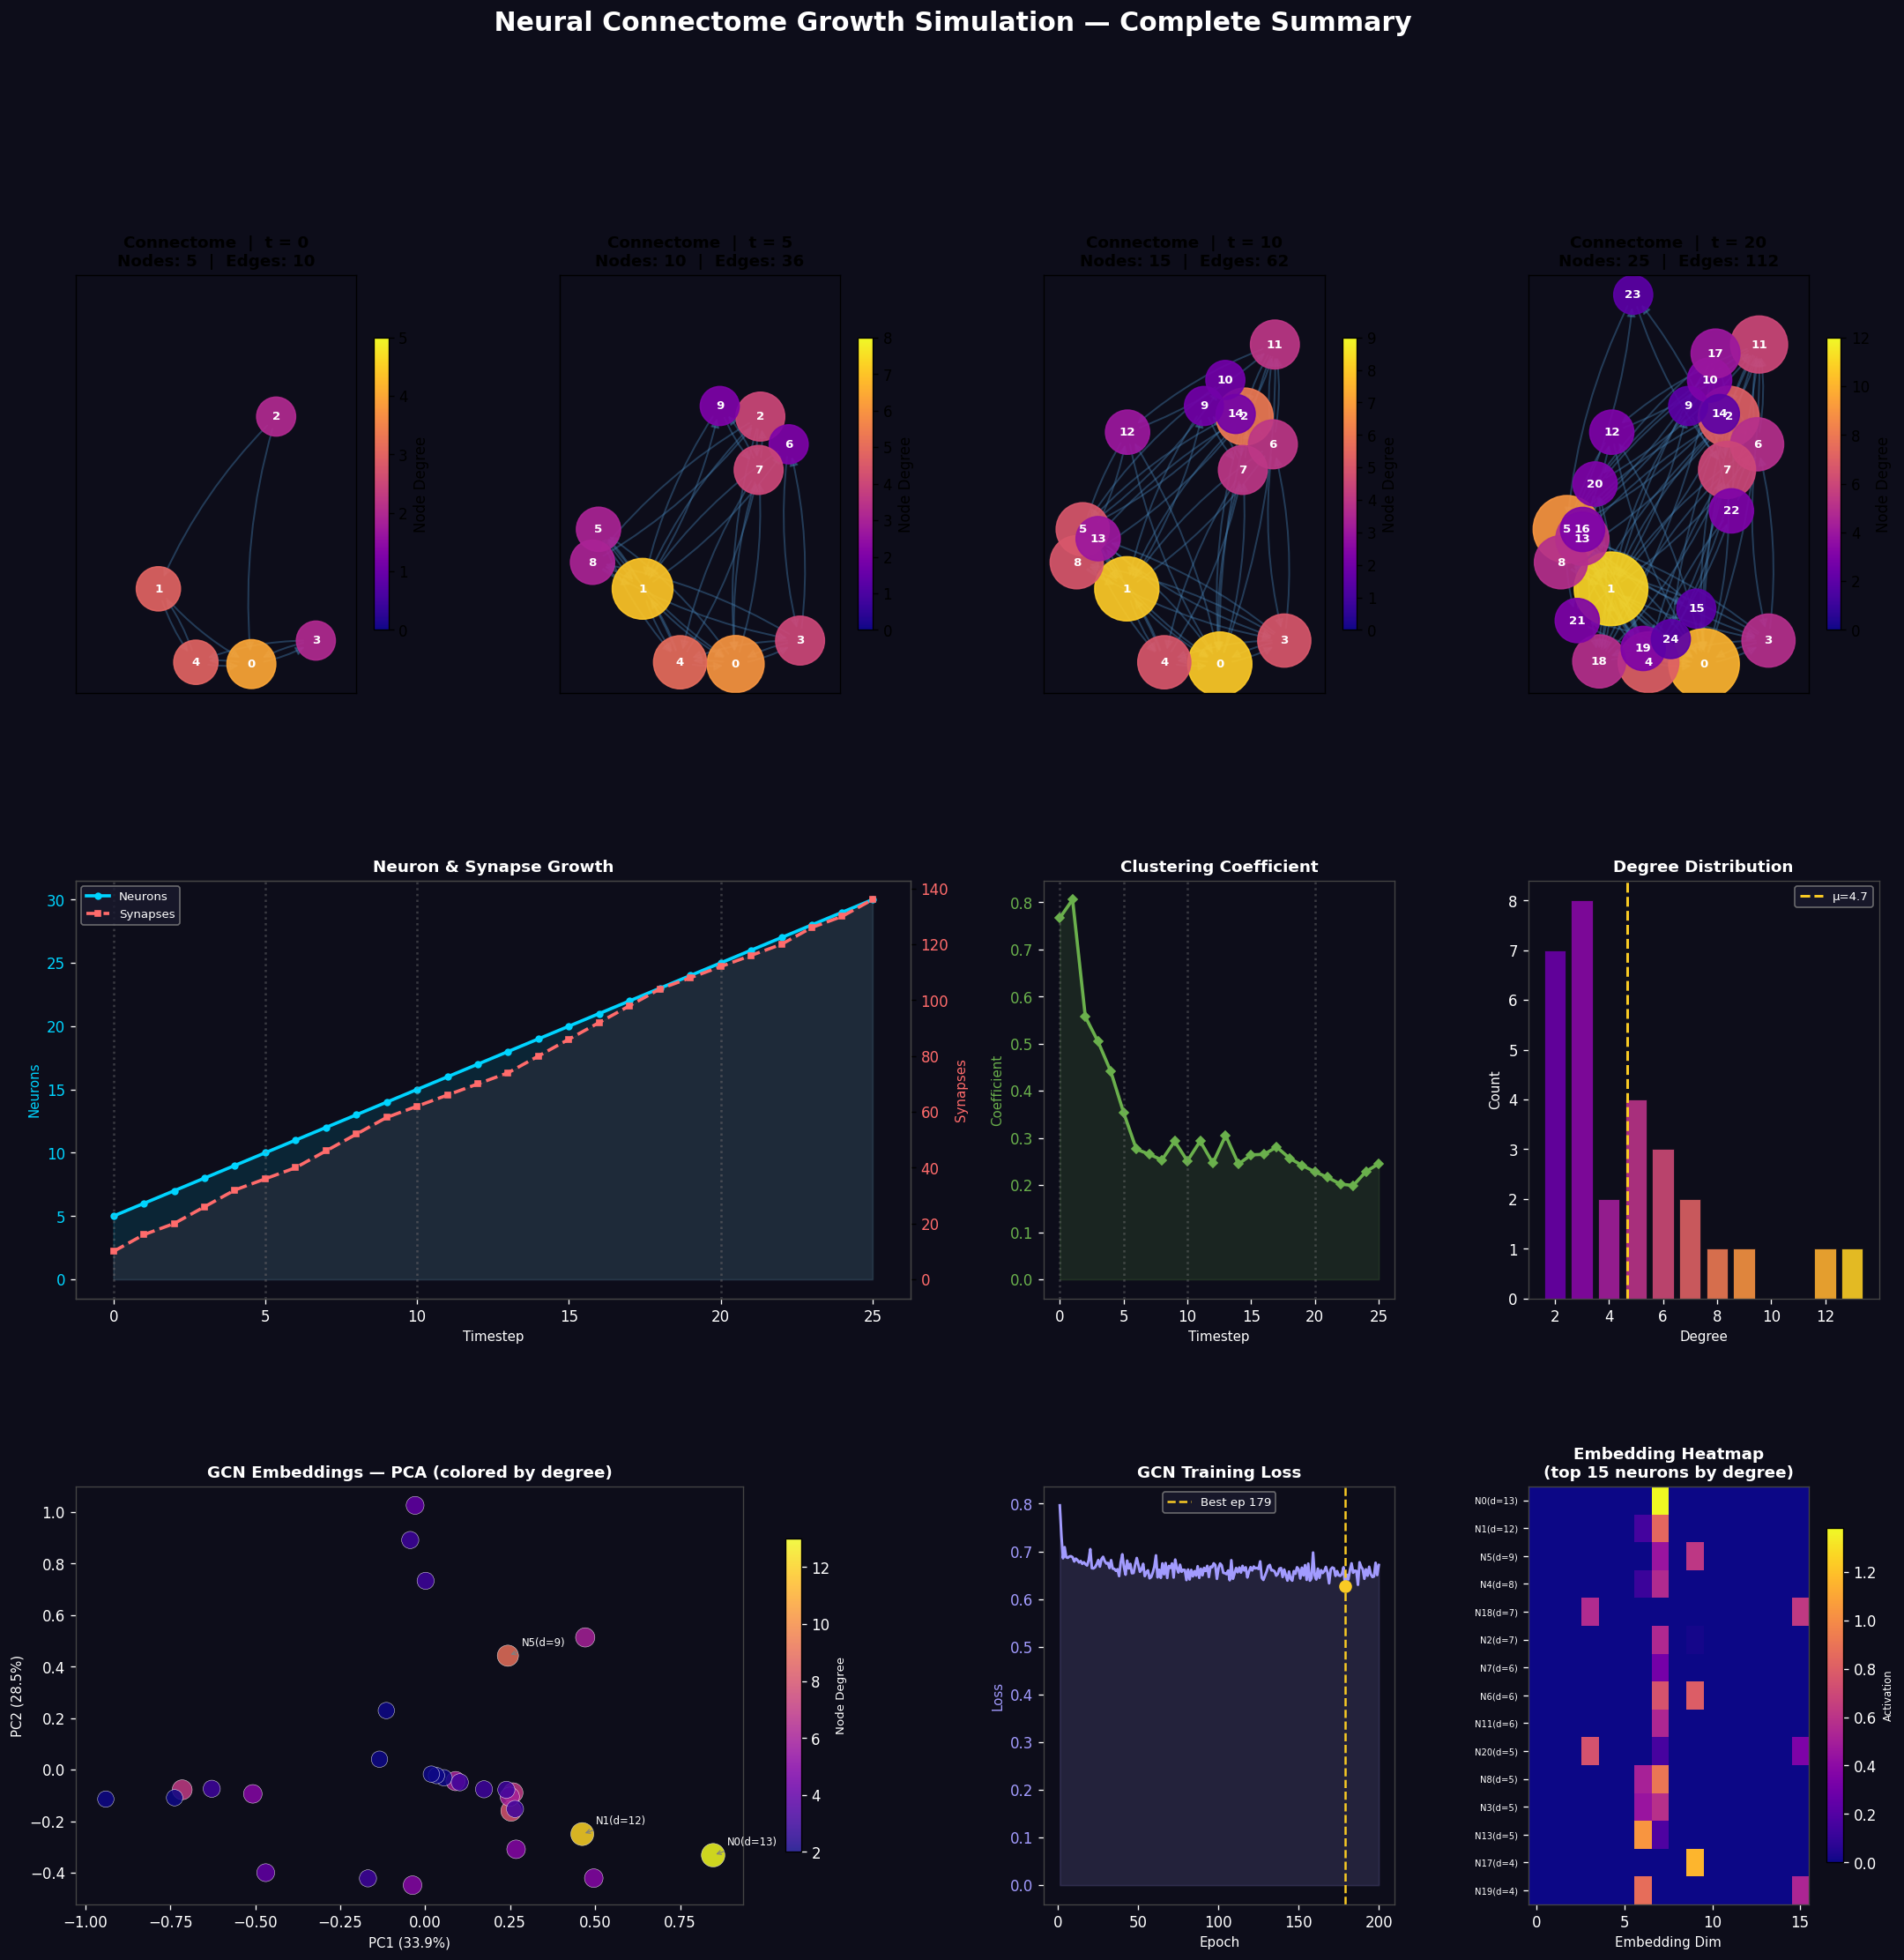

 Saved → /content/master_summary.png


In [30]:
fig = plt.figure(figsize=(22, 20))
fig.patch.set_facecolor('#0d0d1a')
fig.suptitle(
    ' Neural Connectome Growth Simulation — Complete Summary',
    fontsize=18, fontweight='bold', color='white', y=1.005
)

gs = fig.add_gridspec(3, 4,
                      hspace=0.45,
                      wspace=0.38)

# ── Row 1: Connectome snapshots (4 stages) ────────────────
for idx, t in enumerate(SNAPSHOT_STEPS):
    ax  = fig.add_subplot(gs[0, idx])
    G_s = graph_snapshots[t]
    draw_connectome(G_s, ax,
                    title="Connectome", timestep=t)

# ── Row 2 Left (span 2): Nodes & Edges growth ─────────────
ax_ne = fig.add_subplot(gs[1, 0:2])
ax_ne.set_facecolor('#0d0d1a')
ax_ne2 = ax_ne.twinx()

ax_ne.plot(timesteps, nodes_list,
           color='#00d4ff', linewidth=2.2,
           marker='o', markersize=4, label='Neurons')
ax_ne.fill_between(timesteps, nodes_list,
                   alpha=0.12, color='#00d4ff')
ax_ne2.plot(timesteps, edges_list,
            color='#ff6b6b', linewidth=2.2,
            marker='s', markersize=4,
            linestyle='--', label='Synapses')
ax_ne2.fill_between(timesteps, edges_list,
                    alpha=0.08, color='#ff6b6b')
for t in SNAPSHOT_STEPS:
    ax_ne.axvline(x=t, color='gray', linestyle=':', alpha=0.4)

ax_ne.set_title('Neuron & Synapse Growth',
                color='white', fontsize=11, fontweight='bold')
ax_ne.set_xlabel('Timestep', color='white', fontsize=9)
ax_ne.set_ylabel('Neurons', color='#00d4ff', fontsize=9)
ax_ne2.set_ylabel('Synapses', color='#ff6b6b', fontsize=9)
ax_ne.tick_params(colors='white')
ax_ne.tick_params(axis='y', labelcolor='#00d4ff')
ax_ne2.tick_params(axis='y', labelcolor='#ff6b6b')
ax_ne2.set_facecolor('#0d0d1a')
lines1, lab1 = ax_ne.get_legend_handles_labels()
lines2, lab2 = ax_ne2.get_legend_handles_labels()
ax_ne.legend(lines1 + lines2, lab1 + lab2,
             facecolor='#1a1a2e', edgecolor='gray',
             labelcolor='white', fontsize=8, loc='upper left')
for sp in ax_ne.spines.values():  sp.set_edgecolor('#444')
for sp in ax_ne2.spines.values(): sp.set_edgecolor('#444')

# ── Row 2 Mid (span 1): Clustering coefficient ────────────
ax_cl = fig.add_subplot(gs[1, 2])
ax_cl.set_facecolor('#0d0d1a')
ax_cl.plot(timesteps, clust_list,
           color='#6ab04c', linewidth=2.2,
           marker='D', markersize=4)
ax_cl.fill_between(timesteps, clust_list,
                   alpha=0.15, color='#6ab04c')
for t in SNAPSHOT_STEPS:
    ax_cl.axvline(x=t, color='gray', linestyle=':', alpha=0.4)
ax_cl.set_title('Clustering Coefficient',
                color='white', fontsize=11, fontweight='bold')
ax_cl.set_xlabel('Timestep', color='white', fontsize=9)
ax_cl.set_ylabel('Coefficient', color='#6ab04c', fontsize=9)
ax_cl.tick_params(colors='white')
ax_cl.tick_params(axis='y', labelcolor='#6ab04c')
for sp in ax_cl.spines.values(): sp.set_edgecolor('#444')

# ── Row 2 Right (span 1): Degree Distribution ─────────────
ax_dd = fig.add_subplot(gs[1, 3])
ax_dd.set_facecolor('#0d0d1a')
ax_dd.bar(deg_vals, deg_counts,
          color=cm.plasma(np.linspace(0.2, 0.9, len(deg_vals))),
          edgecolor='#0d0d1a', linewidth=0.5, alpha=0.9)
ax_dd.axvline(x=mean_deg, color='#f9ca24',
              linestyle='--', linewidth=1.8,
              label=f'μ={mean_deg:.1f}')
ax_dd.set_title('Degree Distribution',
                color='white', fontsize=11, fontweight='bold')
ax_dd.set_xlabel('Degree', color='white', fontsize=9)
ax_dd.set_ylabel('Count',  color='white', fontsize=9)
ax_dd.tick_params(colors='white')
ax_dd.legend(facecolor='#1a1a2e', edgecolor='gray',
             labelcolor='white', fontsize=8)
for sp in ax_dd.spines.values(): sp.set_edgecolor('#444')

# ── Row 3 Left (span 2): GCN Embeddings PCA ───────────────
ax_pca = fig.add_subplot(gs[2, 0:2])
ax_pca.set_facecolor('#0d0d1a')
sc = ax_pca.scatter(emb_2d[:, 0], emb_2d[:, 1],
                    c=degrees_arr,
                    cmap='plasma',
                    s=100 + degrees_arr * 12,
                    alpha=0.85,
                    edgecolors='white',
                    linewidths=0.3)
for idx in top_hubs:
    node = nodes_list_sorted[idx]
    ax_pca.annotate(
        f'N{node}(d={degrees_arr[idx]})',
        xy=(emb_2d[idx, 0], emb_2d[idx, 1]),
        xytext=(emb_2d[idx, 0] + 0.04,
                emb_2d[idx, 1] + 0.04),
        color='white', fontsize=7,
        arrowprops=dict(arrowstyle='->',
                        color='gray', lw=0.7))
cbar = plt.colorbar(sc, ax=ax_pca, shrink=0.75)
cbar.set_label('Node Degree', color='white', fontsize=8)
cbar.ax.yaxis.set_tick_params(color='white')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='white')
ax_pca.set_title('GCN Embeddings — PCA (colored by degree)',
                 color='white', fontsize=11, fontweight='bold')
ax_pca.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}%)',
                  color='white', fontsize=9)
ax_pca.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}%)',
                  color='white', fontsize=9)
ax_pca.tick_params(colors='white')
for sp in ax_pca.spines.values(): sp.set_edgecolor('#444')

# ── Row 3 Mid (span 1): Training Loss ─────────────────────
ax_loss = fig.add_subplot(gs[2, 2])
ax_loss.set_facecolor('#0d0d1a')
ax_loss.plot(range(1, EPOCHS + 1), loss_log,
             color='#a29bfe', linewidth=1.8)
ax_loss.fill_between(range(1, EPOCHS + 1), loss_log,
                     alpha=0.15, color='#a29bfe')
best_ep = loss_log.index(min(loss_log)) + 1
ax_loss.axvline(x=best_ep, color='#f9ca24',
                linestyle='--', linewidth=1.5,
                label=f'Best ep {best_ep}')
ax_loss.scatter([best_ep], [min(loss_log)],
                color='#f9ca24', s=60, zorder=5)
ax_loss.set_title('GCN Training Loss',
                  color='white', fontsize=11, fontweight='bold')
ax_loss.set_xlabel('Epoch', color='white', fontsize=9)
ax_loss.set_ylabel('Loss', color='#a29bfe', fontsize=9)
ax_loss.tick_params(colors='white')
ax_loss.tick_params(axis='y', labelcolor='#a29bfe')
ax_loss.legend(facecolor='#1a1a2e', edgecolor='gray',
               labelcolor='white', fontsize=8)
for sp in ax_loss.spines.values(): sp.set_edgecolor('#444')

# ── Row 3 Right (span 1): Embedding Heatmap ───────────────
ax_hm = fig.add_subplot(gs[2, 3])
ax_hm.set_facecolor('#0d0d1a')
sort_idx   = np.argsort(degrees_arr)[::-1][:15]  # top 15 for clarity
emb_top    = embeddings_np[sort_idx]
labels_top = [f"N{nodes_list_sorted[i]}(d={degrees_arr[i]})"
              for i in sort_idx]
im2 = ax_hm.imshow(emb_top, aspect='auto',
                   cmap='plasma', interpolation='nearest')
ax_hm.set_yticks(range(len(labels_top)))
ax_hm.set_yticklabels(labels_top, fontsize=6, color='white')
ax_hm.set_xlabel('Embedding Dim', color='white', fontsize=9)
ax_hm.set_title('Embedding Heatmap\n(top 15 neurons by degree)',
                color='white', fontsize=11, fontweight='bold')
ax_hm.tick_params(colors='white')
for sp in ax_hm.spines.values(): sp.set_edgecolor('#444')
cbar2 = plt.colorbar(im2, ax=ax_hm, shrink=0.8)
cbar2.set_label('Activation', color='white', fontsize=7)
cbar2.ax.yaxis.set_tick_params(color='white')
plt.setp(cbar2.ax.yaxis.get_ticklabels(), color='white')

plt.savefig('/content/master_summary.png',
            dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()
print(" Saved → /content/master_summary.png")

In [31]:
import os
import shutil

# -- List all saved figures --
output_files = [
    '/content/connectome_t0.png',
    '/content/connectome_growth_stages.png',
    '/content/growth_nodes_edges.png',
    '/content/topology_metrics.png',
    '/content/degree_distribution.png',
    '/content/full_dashboard.png',
    '/content/gcn_embeddings_pca.png',
    '/content/gcn_diagnostics.png',
]

print(" Output Files Summary")
print("=" * 52)
for f in output_files:
    if os.path.exists(f):
        size_kb = os.path.getsize(f) / 1024
        print(f"    {os.path.basename(f):<40} {size_kb:>6.1f} KB")
    else:
        print(f"    {os.path.basename(f):<40} NOT FOUND")

# -- Optional: Mount Drive and copy files --
SAVE_TO_DRIVE = False    # ← Set True to save to Google Drive

if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')

    drive_folder = '/content/drive/MyDrive/connectome_simulation'
    os.makedirs(drive_folder, exist_ok=True)

    for f in output_files:
        if os.path.exists(f):
            shutil.copy(f, drive_folder)
            print(f"  📤 Copied {os.path.basename(f)} → Drive")

    print(f"\n   All files saved to Google Drive: {drive_folder}")
else:
    print("\n    To save to Google Drive, set SAVE_TO_DRIVE = True")
    print("     Files remain available at /content/ "
          "until runtime resets")

 Output Files Summary
    connectome_t0.png                          54.1 KB
    connectome_growth_stages.png              780.2 KB
    growth_nodes_edges.png                    100.2 KB
    topology_metrics.png                      110.6 KB
    degree_distribution.png                    41.3 KB
    full_dashboard.png                        158.7 KB
    gcn_embeddings_pca.png                    145.7 KB
    gcn_diagnostics.png                       151.3 KB

    To save to Google Drive, set SAVE_TO_DRIVE = True
     Files remain available at /content/ until runtime resets


In [32]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

import shutil, os

# Create a folder in your Drive
folder = '/content/drive/MyDrive/connectome_simulation'
os.makedirs(folder, exist_ok=True)

# List of all output files
output_files = [
    '/content/connectome_t0.png',
    '/content/connectome_growth_stages.png',
    '/content/growth_nodes_edges.png',
    '/content/topology_metrics.png',
    '/content/degree_distribution.png',
    '/content/full_dashboard.png',
    '/content/gcn_embeddings_pca.png',
    '/content/gcn_diagnostics.png',
    '/content/master_summary.png',
]

# Copy all to Drive
for f in output_files:
    if os.path.exists(f):
        shutil.copy(f, folder)
        print(f" Saved: {os.path.basename(f)}")
    else:
        print(f" Not found: {os.path.basename(f)}")

print(f"\n All files saved to → {folder}")

Mounted at /content/drive
 Saved: connectome_t0.png
 Saved: connectome_growth_stages.png
 Saved: growth_nodes_edges.png
 Saved: topology_metrics.png
 Saved: degree_distribution.png
 Saved: full_dashboard.png
 Saved: gcn_embeddings_pca.png
 Saved: gcn_diagnostics.png
 Saved: master_summary.png

 All files saved to → /content/drive/MyDrive/connectome_simulation
